# New sensitivity figures for the DNA-storage paper

This notebook turns the sensitivity analyses in [the calculator](https://dna-calc.el-shaikh.com) into Matplotlib figures matching **Figures.ipynb** and **preamble.py**: Seaborn's deep palette, white backgrounds, bold labels, and Computer Modern mathematics.

**Start here:** select this repository's Python environment and **Run All**. The setup cell and helpers must run first; subsequently each figure section can run independently. No downloads, Streamlit server, browser, or LaTeX installation are needed. Dependencies are already in the repository's requirements (NumPy, pandas, Matplotlib, Seaborn, PyYAML; IPython/Jupyter for the notebook).

- **M1 — proposed main-article figure:** one-at-a-time sensitivity of DNA lifecycle cost, for archives starting in 2025 and 2050.
- **S1–S11 — supplementary candidates:** cost advantage, synthesis thresholds, future-start scenarios, two-rate sensitivity, discounting, durability, synthesis-cost floors, sequencing/retention heatmaps, and break-even line comparisons across synthesis decline rates.
- Every figure exports to a dedicated folder as **PDF + SVG + 300-dpi PNG**. Underlying numerical tables are saved as CSV.
- The final cell builds **Supplementary_Sensitivity_Figures.pdf**, including captions, plus a caption list and reproducibility manifest.

The notebook writes only beneath `figs/paper_sensitivity/` in this code repository. It never edits or exports into the Overleaf project. Figure numbers are provisional.

## Model choices to review before incorporating figures

The calculations reuse the local calculator's `economic_dna` API, not the older symbolic notebook helpers. These are scenario analyses, not forecasts or confidence intervals.

1. The baseline workload matches the manuscript: 1 TB, 1,000 objects of 1,000 MB, 1% retrieval/year, 100 years, no discounting, DNA durability 1,000 years and tape durability 30 years. Decimal capacity units are retained.
2. The DNA price anchor is **2025**, using the paper's historical fits. The website currently anchors editable prices in 2026. Re-anchoring preserves the baseline cost trajectory but deliberately makes decline-rate perturbations operate forward from 2025; thus perturbed results need not equal the website's 2026-anchored tornado.
3. The continuous coefficients \(b=0.1671\) and \(0.4791\) correspond to annual declines \(100(1-e^{-b})=15.39\%\) and \(38.07\%\), respectively. A coefficient of 0.4791 is **not** a 47.91% annual percentage decline. Labels here use actual annual percentages.
4. A horizon of \(d\) years includes \(y_0,\ldots,y_0+d-1\). This follows the calculator; some legacy figure helpers include the endpoint and therefore charge an extra year.
5. Tape follows the **website's disaggregated model**: media USD 6.39/TB, hardware USD 6.86/TB amortized over 30 years, energy USD 0.05/TB/year, with annual declines of 20%, 0%, and 15%. It is not the manuscript's simpler uniform-10%-decline tape variant.
6. Cloud tariffs remain the repository's 2025 assumptions, not newly collected prices. All costs are expressed in constant 2025 USD, as in `assumptions.yaml`. DNA maintenance is zero; unmodelled laboratory operations, access latency, and other overheads are not added here.
7. A missing nonnegative break-even price means sequencing alone exceeds the comparator's total cost. Such cases remain missing; negative theoretical subsidies are never presented as achievable synthesis prices.

Edit the configuration below to explore alternatives. Captions and CSVs record the actual settings. Keep the sidecar manifest with any exported figures.


In [1]:
from pathlib import Path
from dataclasses import asdict, replace
import hashlib
import importlib.metadata
import json
import math
import os
import subprocess
import sys
import textwrap
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
import seaborn as sns
from IPython.display import display

# Open this notebook with the repository as its working directory.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "economic_dna" / "scenario.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from the Economic_DNA repository.")
sys.path.insert(0, str(ROOT))

from economic_dna import (
    Scenario, dna_cost_sensitivity, dna_cost_advantage,
    simulate_scenario, simulate_start_years, find_breakeven_synthesis_cost,
)
from economic_dna.sensitivity import DNA_SENSITIVITY_PARAMETERS

# These are explicit paper/calculator assumptions, not live vendor prices.
BASE = Scenario(
    archive_size_tb=1.0, average_asset_size_mb=1000.0,
    annual_retrieval_percent=1.0, start_year=2025, horizon_years=100,
    discount_rate_percent=0.0, dna_cost_base_year=2025,
    dna_synthesis_cost_per_mb=0.3193 * np.exp(-0.1671 * 25) * 4e6,
    dna_sequencing_cost_per_mb=35.036 * np.exp(-0.4791 * (2025 - 2011.5)) * 4,
    synthesis_decline_percent=100 * (1 - np.exp(-0.1671)),
    sequencing_decline_percent=100 * (1 - np.exp(-0.4791)),
    dna_durability_years=1000, tape_durability_years=30,
    amazon_price_base_year=2025,
    amazon_put_usd_per_request=0.00005,
    amazon_bulk_restore_usd_per_request=0.000025,
    amazon_bulk_retrieval_usd_per_mb=0.0025 / 1024,
    amazon_storage_usd_per_mb_month=0.00099 / 1024,
    amazon_decline_percent=10.0,
    azure_price_base_year=2025,
    azure_write_usd_per_request=0.00001,
    azure_read_usd_per_request=0.0005,
    azure_retrieval_usd_per_mb=0.02 / 1024,
    azure_storage_usd_per_mb_month=0.002 / 1024,
    azure_decline_percent=10.0,
    tape_price_base_year=2025, tape_media_usd_per_tb=6.39,
    tape_hardware_usd_per_tb=6.86, tape_energy_usd_per_tb_year=0.05,
    tape_media_decline_percent=20.0, tape_hardware_decline_percent=0.0,
    tape_energy_decline_percent=15.0,
    technologies=("DNA", "Amazon Deep Archive", "Azure Blob Archive", "Tape On-premise"),
)
FUTURE_START = 2050
FINAL_START = 2400
RARE_RETRIEVAL = 0.001  # percent/year; 1,000x less than the baseline's 1%
COMPARATOR = "Amazon Deep Archive"
# Point this environment variable at a temporary directory for validation only.
OUT = Path(os.environ.get("DNA_PAPER_FIGURE_OUTPUT", str(ROOT / "figs" / "paper_sensitivity")))
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white", context="notebook", font_scale=1.1, palette="deep")
mpl.rcParams.update({
    "mathtext.fontset": "cm", "axes.labelweight": "bold",
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "lines.linewidth": 2,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "savefig.dpi": 300, "figure.dpi": 110,
})
PALETTE = sns.color_palette("deep")
COLORS = dict(zip(BASE.technologies, (PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3])))
STYLES = dict(zip(BASE.technologies, ("-", "--", "-.", ":")))
PEERS = [t for t in BASE.technologies if t != "DNA"]
FIGURES, CAPTIONS, TABLES, SCENARIOS = {}, {}, {}, {}

display(pd.DataFrame({
    "Parameter": ["Archive (TB)", "Objects", "Object size (MB)", "Annual retrieval (%)",
                  "Start year", "Retention (years)", "Synthesis (USD/MB at anchor)",
                  "Sequencing (USD/MB at anchor)", "Synthesis annual decline (%)",
                  "Sequencing annual decline (%)"],
    "Value": [BASE.archive_size_tb, BASE.number_of_assets, BASE.average_asset_size_mb,
              BASE.annual_retrieval_percent, BASE.start_year, BASE.horizon_years,
              BASE.dna_synthesis_cost_per_mb, BASE.dna_sequencing_cost_per_mb,
              BASE.synthesis_decline_percent, BASE.sequencing_decline_percent],
}))
print(f"Output folder: {OUT}")


,Parameter,Value
0,Archive (TB),1.000000
1,Objects,1000.000000
2,Object size (MB),1000.000000
3,Annual retrieval (%),1.000000
4,Start year,2025.000000
5,Retention (years),100.000000
6,Synthesis (USD/MB at anchor),19588.163110
7,Sequencing (USD/MB at anchor),0.217582
8,Synthesis annual decline (%),15.388500
9,Sequencing annual decline (%),38.065945


Output folder: C:\Users\Alex\PycharmProjects\Economic_DNA\figs\paper_sensitivity


In [2]:
def tidy(ax, xlabel=None, ylabel=None, title=None):
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, loc="left", pad=12)
    ax.grid(axis="y", color="0.90", linewidth=0.6)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

def legend(ax, **kwargs):
    return ax.legend(frameon=False, **kwargs)

def totals(scenario, present_value=False):
    column = "present_value_usd" if present_value else "total_cost_usd"
    return simulate_scenario(scenario).totals.set_index("technology")[column]

def describe(s):
    return (f"{s.archive_size_tb:g} TB; {s.average_asset_size_mb:g} MB/object; "
            f"{s.annual_retrieval_percent:g}% retrieval/year; start {s.start_year}; "
            f"{s.horizon_years} years; discount {s.discount_rate_percent:g}%/year")

def record(name, fig, caption, tables, scenarios):
    """Save one figure and retain it for the final vector-PDF compilation."""
    fig.canvas.draw()
    for extension in ("pdf", "svg", "png"):
        fig.savefig(OUT / f"{name}.{extension}", bbox_inches="tight",
                    transparent=extension != "png", facecolor="white" if extension == "png" else "none")
    for suffix, frame in tables.items():
        table_name = f"{name}_{suffix}"
        TABLES[table_name] = frame.copy()
        frame.to_csv(OUT / f"{table_name}.csv", index=False)
    FIGURES[name] = fig
    CAPTIONS[name] = caption
    SCENARIOS[name] = {key: asdict(value) for key, value in scenarios.items()}
    display(fig)
    plt.close(fig)

def threshold_at_start(scenario, present_value=False):
    """Public solver reports the anchor-year price; also expose start-year prices."""
    frame = find_breakeven_synthesis_cost(scenario, present_value).copy()
    factor = (1 - scenario.synthesis_decline_percent / 100) ** (
        scenario.start_year - scenario.dna_cost_base_year)
    frame["threshold_start_usd_per_mb"] = (
        pd.to_numeric(frame["breakeven_synthesis_cost_usd_per_mb"], errors="coerce") * factor
    )
    frame["reachable"] = frame["threshold_start_usd_per_mb"].notna()
    frame["start_year"] = scenario.start_year
    frame["annual_retrieval_percent"] = scenario.annual_retrieval_percent
    return frame

def future_at_price(scenario, price_at_start):
    factor = (1 - scenario.synthesis_decline_percent / 100) ** (
        scenario.start_year - scenario.dna_cost_base_year)
    return replace(scenario, dna_synthesis_cost_per_mb=float(price_at_start / factor))

def dna_cost_with_floor(scenario, floor_usd_per_mb=0.0):
    """Supplement-only extension: clamp synthesis USD/MB in every calendar year.

    Sequencing, workload, and replacement timing are identical to the website.
    A floor of zero reproduces its DNA total. This extension is not in the app.
    """
    if floor_usd_per_mb < 0:
        raise ValueError("The synthesis floor must be nonnegative.")
    years = np.arange(scenario.start_year, scenario.start_year + scenario.horizon_years)
    prices = scenario.dna_synthesis_cost_per_mb * (
        1 - scenario.synthesis_decline_percent / 100) ** (years - scenario.dna_cost_base_year)
    write_mask = (years - scenario.start_year) % scenario.dna_durability_years == 0
    write = scenario.archive_size_mb * np.maximum(prices, floor_usd_per_mb) * write_mask
    read = (scenario.archive_size_mb * scenario.annual_retrieval_percent / 100
            * scenario.dna_sequencing_cost_per_mb
            * (1 - scenario.sequencing_decline_percent / 100) ** (years - scenario.dna_cost_base_year))
    return float((write + read).sum())

# Show the baseline components before plotting: this is also a useful audit table.
baseline_components = simulate_scenario(BASE).totals
display(baseline_components.round(6))
baseline_components.to_csv(OUT / "baseline_cost_components.csv", index=False)

# S8/S9 configuration: the baseline is always shown alongside this explicit what-if.
HEATMAP_SYNTHESIS_DECLINE = 60.0  # actual annual percentage, anchored in 2025
HEATMAP_MAX_RETENTION = 10_000   # model's supported horizon limit
from scipy.optimize import brentq

def heatmap_evaluator(scenario, max_horizon):
    """Scale public-model annual cost streams; retain its prices and replacement schedule."""
    flat = simulate_scenario(replace(
        scenario, horizon_years=int(max_horizon), sequencing_decline_percent=0.0,
        amazon_decline_percent=0.0, technologies=("DNA", "Amazon Deep Archive"),
    )).yearly
    dna = flat[flat.technology == "DNA"]
    amazon = flat[flat.technology == "Amazon Deep Archive"]
    write = dna.write_cost_usd.to_numpy()
    read = dna.read_cost_usd.to_numpy()
    cloud = amazon.total_cost_usd.to_numpy()
    dna_age = dna.year.to_numpy() - scenario.dna_cost_base_year
    cloud_age = amazon.year.to_numpy() - scenario.amazon_price_base_year

    def dna_cumulative(rate):
        return np.cumsum(write + read * np.power(1 - rate / 100, dna_age))

    def cloud_cumulative(rate):
        return np.cumsum(cloud * np.power(1 - rate / 100, cloud_age))

    def dna_total(rate, horizon):
        return float(write[:horizon].sum() + np.dot(
            read[:horizon], np.power(1 - rate / 100, dna_age[:horizon])))

    def cloud_total(rate, horizon):
        return float(np.dot(cloud[:horizon], np.power(1 - rate / 100, cloud_age[:horizon])))

    return dna_cumulative, cloud_cumulative, dna_total, cloud_total

def parity_root(function, lower, upper):
    """A root exists only with a bracket (or exact endpoint equality)."""
    left, right = function(lower), function(upper)
    if left == 0:
        return float(lower)
    if right == 0:
        return float(upper)
    if np.sign(left) == np.sign(right):
        return np.nan
    return float(brentq(function, lower, upper, xtol=1e-11))

def joint_heatmap_panels(grids, boundaries, scenarios, x_column, xlabel, reference_x,
                         log_x=False):
    """Shared S4 colour convention; draw numerically solved parity boundaries."""
    limit = max(1.0, float(np.ceil(np.abs(grids.log10_cost_ratio).max())))
    fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.2))
    fig.subplots_adjust(left=0.065, right=0.88, bottom=0.20, top=0.85, wspace=0.13)
    fig.suptitle(
        f"DNA / Amazon cost sensitivity: archive starts in {next(iter(scenarios.values())).start_year}",
        fontsize=14, fontweight="bold", y=0.985,
    )
    for index, ((key, scenario), ax) in enumerate(zip(scenarios.items(), axes)):
        frame = grids[grids.scenario == key]
        grid = frame.pivot(index="amazon_decline_percent", columns=x_column,
                           values="log10_cost_ratio")
        mesh = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), shading="auto",
                             cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
                             rasterized=True)
        boundary = boundaries[boundaries.scenario == key].sort_values(x_column)
        valid = boundary.dropna(subset=[x_column, "amazon_decline_percent"])
        if len(valid):
            # NaNs split disjoint segments; no line is fabricated beyond a root.
            ax.plot(boundary[x_column], boundary.amazon_decline_percent,
                    color="black", lw=2, label="Cost parity", zorder=5)
            point = valid.iloc[len(valid) // 2]
            ax.annotate("Cost parity", (point[x_column], point.amazon_decline_percent),
                        xytext=(8, 10), textcoords="offset points", fontsize=10,
                        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
                        zorder=6)
        else:
            ax.text(0.5, 0.68, "No cost parity\nwithin the displayed range",
                    ha="center", va="center", transform=ax.transAxes,
                    bbox={"facecolor": "white", "alpha": 0.92, "edgecolor": "none"}, fontsize=11)
        ax.scatter(reference_x, scenario.amazon_decline_percent, marker="*", s=160,
                   color="white", edgecolor="black", linewidth=1.2, zorder=7)
        star_label = (
            "Baseline DNA sequencing\nand Amazon decline rates"
            if x_column == "sequencing_decline_percent"
            else "Baseline retention\nand Amazon decline rate"
        )
        ax.annotate(
            star_label, (reference_x, scenario.amazon_decline_percent),
            xytext=(30, 12), textcoords="offset points", ha="left", va="bottom",
            fontsize=9, zorder=8,
            arrowprops={"arrowstyle": "->", "color": "0.2", "lw": 1.1, "shrinkB": 9},
            bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "none", "pad": 2.5},
        )
        if log_x:
            ax.set_xscale("log")
        ax.set_xlim(grid.columns.min(), grid.columns.max())
        ax.set_ylim(grid.index.min(), grid.index.max())
        tidy(ax, xlabel, "Amazon annual cost decline (%)" if index == 0 else None,
             f"({chr(97 + index)}) Synthesis decline: {scenario.synthesis_decline_percent:.2f}%/year")
        ax.grid(False)
    colorbar_ax = fig.add_axes([0.91, 0.20, 0.015, 0.65])
    fig.colorbar(mesh, cax=colorbar_ax,
                 label=r"$\log_{10}(C_{\mathrm{DNA}}/C_{\mathrm{Amazon}})$")
    fig.legend(handles=[
        Line2D([], [], color="black", lw=2, label="Cost parity (when present)"),
    ], loc="lower center", bbox_to_anchor=(0.48, 0.02), ncol=1, frameon=False)
    return fig

# S10/S11: illustrative annual synthesis declines, with all prices anchored as in BASE.
PARITY_SYNTHESIS_RATES = (50.0, 55.0, 60.0, 65.0)
PARITY_AMAZON_RANGE = (0.0, 30.0)

def synthesis_parity_lines(kind, x_values):
    """Solve Amazon decline at cost equality for each synthesis scenario and x."""
    x_values = np.asarray(x_values)
    max_horizon = BASE.horizon_years if kind == "sequencing" else int(x_values.max())
    scenarios = {
        f"synthesis_{rate:g}": replace(
            BASE, start_year=FUTURE_START, synthesis_decline_percent=float(rate),
            technologies=("DNA", "Amazon Deep Archive"),
        )
        for rate in (*PARITY_SYNTHESIS_RATES, float(BASE.synthesis_decline_percent))
    }
    rows = []
    for key, scenario in scenarios.items():
        dna_cumulative, _, dna_total, cloud_total = heatmap_evaluator(scenario, max_horizon)
        if kind == "retention":
            dna_values = dna_cumulative(scenario.sequencing_decline_percent)[x_values.astype(int) - 1]
        else:
            dna_values = [dna_total(float(x), BASE.horizon_years) for x in x_values]
        for x, dna_cost in zip(x_values, dna_values):
            horizon = BASE.horizon_years if kind == "sequencing" else int(x)
            def difference(rate):
                return dna_cost - cloud_total(rate, horizon)
            cloud_rate = parity_root(difference, *PARITY_AMAZON_RANGE)
            if np.isfinite(cloud_rate):
                status = "parity_in_range"
            elif difference(PARITY_AMAZON_RANGE[0]) > 0:
                status = "DNA_more_expensive_throughout_range"
            else:
                status = "DNA_cheaper_throughout_range"
            rows.append({
                "scenario": key,
                "synthesis_decline_percent": scenario.synthesis_decline_percent,
                "sequencing_decline_percent": float(x) if kind == "sequencing" else scenario.sequencing_decline_percent,
                "retention_years": horizon,
                "amazon_decline_percent": cloud_rate,
                "dna_cost_usd": float(dna_cost),
                "comparison_cost_usd": cloud_total(cloud_rate, horizon) if np.isfinite(cloud_rate) else np.nan,
                "root_exists": bool(np.isfinite(cloud_rate)), "status": status,
            })
    return pd.DataFrame(rows), scenarios

def plot_synthesis_parity_lines(frame, kind):
    x_column = "sequencing_decline_percent" if kind == "sequencing" else "retention_years"
    xlabel = "DNA sequencing annual decline (%)" if kind == "sequencing" else "Data retention (years)"
    fig, ax = plt.subplots(figsize=(9.5, 6.0), layout="constrained")
    for index, rate in enumerate(PARITY_SYNTHESIS_RATES):
        part = frame[frame.synthesis_decline_percent == rate].sort_values(x_column)
        ax.plot(part[x_column], part.amazon_decline_percent, color=PALETTE[index],
                ls=("-", "--", "-.", ":")[index], lw=2.2, label=f"{rate:g}%/year")
    baseline = frame[np.isclose(frame.synthesis_decline_percent, BASE.synthesis_decline_percent)]
    if baseline.root_exists.any():
        ax.plot(baseline[x_column], baseline.amazon_decline_percent,
                color="0.25", ls=(0, (1, 2)), label=f"Baseline: {BASE.synthesis_decline_percent:.2f}%/year")
    else:
        ax.text(0.98, 0.98, f"Baseline synthesis ({BASE.synthesis_decline_percent:.2f}%/year):\n"
                "no parity within this range", ha="right", va="top",
                transform=ax.transAxes, fontsize=9)
    reference_x = BASE.sequencing_decline_percent if kind == "sequencing" else BASE.horizon_years
    label = ("Baseline DNA sequencing\nand Amazon decline rates" if kind == "sequencing"
             else "Baseline retention\nand Amazon decline rate")
    ax.scatter(reference_x, BASE.amazon_decline_percent, marker="*", s=160, facecolor="white",
               edgecolor="black", linewidth=1.2, zorder=5)
    ax.annotate(label, (reference_x, BASE.amazon_decline_percent),
                xytext=(34, 0), textcoords="offset points", ha="left", va="center",
                fontsize=9, zorder=6,
                arrowprops={"arrowstyle": "->", "color": "0.2", "lw": 1.1, "shrinkB": 9},
                bbox={"facecolor": "white", "alpha": 0.92, "edgecolor": "none", "pad": 2.5})
    if kind == "retention":
        ax.set_xscale("log")
    ax.set_xlim(frame[x_column].min(), frame[x_column].max())
    ax.set_ylim(*PARITY_AMAZON_RANGE)
    tidy(ax, xlabel, "Amazon annual cost decline at parity (%)",
         f"DNA / Amazon cost parity: archive starts in {FUTURE_START}")
    legend(ax, title="Annual synthesis decline", loc="upper left", ncol=2)
    return fig


,technology_key,technology,write_cost_usd,read_cost_usd,maintenance_cost_usd,total_cost_usd,present_value_usd,total_cost_per_tb_usd,present_value_per_tb_usd
0,DNA,DNA,1.958816e+10,5715.922420,0.000000,1.958817e+10,1.958817e+10,1.958817e+10,1.958817e+10
1,Amazon Deep Archive,Amazon Deep Archive,5.000000e-02,0.246634,116.012543,1.163092e+02,1.163092e+02,1.163092e+02,1.163092e+02
2,Azure Blob Archive,Azure Blob Archive,1.000000e-02,2.003072,234.368775,2.363818e+02,2.363818e+02,2.363818e+02,2.363818e+02
3,Tape On-premise,Tape On-premise,6.397920e+00,0.000000,23.200000,2.959792e+01,2.959792e+01,2.959792e+01,2.959792e+01


## M1 — proposed main figure: what drives DNA lifecycle cost?

Two tornado panels compare the paper's start year with a future deployment year. The horizontal coordinate is **cost divided by that panel's baseline cost**, on a logarithmic axis; the dashed line is 1. Low and high refer to the **input**, not to the resulting cost. Each input varies by ±50% while the others remain fixed. The zero baseline discount rate uses the calculator's 0–5% fallback, but has no effect here because costs are undiscounted.

A factor-of-two difference remains visible while the much stronger future sensitivity to synthesis decline fits on the same axis. Tiny effects should be read from the CSV, not interpreted as exact zero. The notebook does not describe these perturbations as an uncertainty interval.


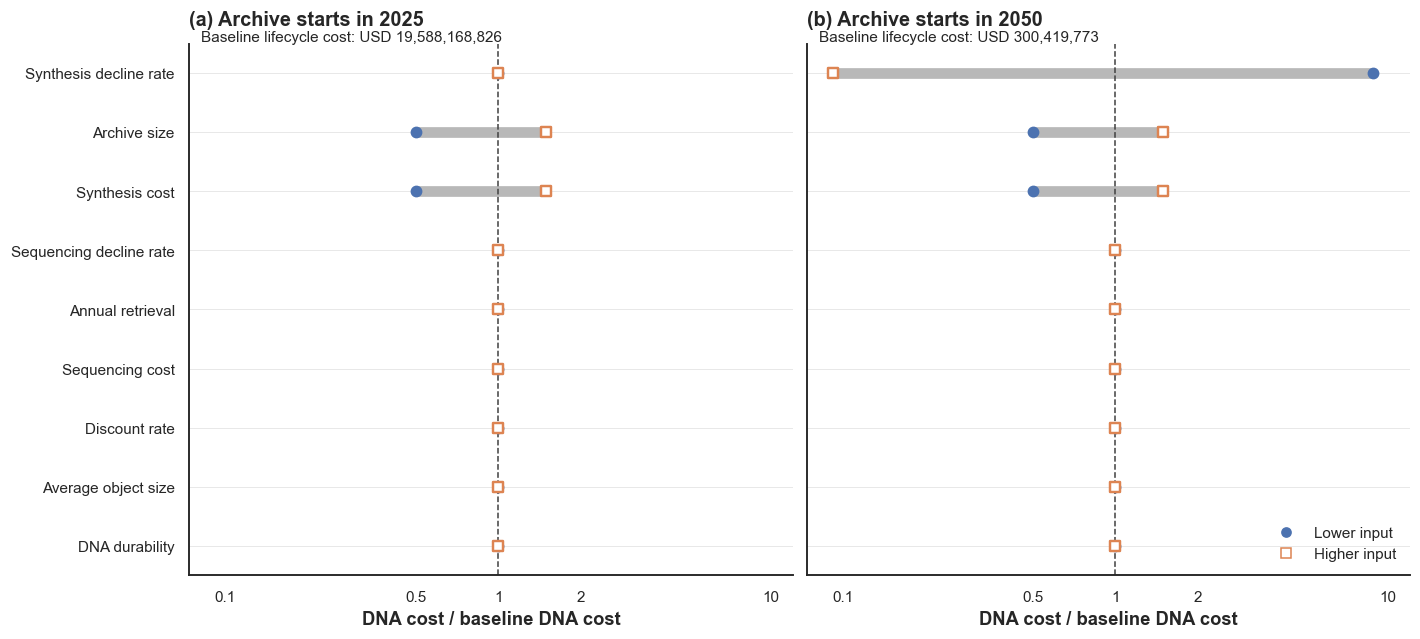

In [3]:
m1_scenarios = {"baseline": BASE, "future": replace(BASE, start_year=FUTURE_START)}
frames = []
for label, scenario in m1_scenarios.items():
    frame = dna_cost_sensitivity(scenario, use_present_value=False)
    frame["scenario"] = label
    frame["start_year"] = scenario.start_year
    frame["low_ratio"] = frame.low_cost / frame.baseline_cost
    frame["high_ratio"] = frame.high_cost / frame.baseline_cost
    frames.append(frame)
m1 = pd.concat(frames, ignore_index=True)
magnitude = m1.assign(effect=np.maximum(abs(np.log10(m1.low_ratio)),
                                      abs(np.log10(m1.high_ratio))))
order = magnitude.groupby("parameter").effect.max().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.7), sharey=True, layout="constrained")
for index, ((label, scenario), ax) in enumerate(zip(m1_scenarios.items(), axes)):
    frame = m1[m1.scenario == label].set_index("parameter").loc[order]
    for y, row in enumerate(frame.itertuples()):
        ax.plot([row.low_ratio, row.high_ratio], [y, y], color="0.72", lw=7,
                solid_capstyle="butt", zorder=1)
        ax.scatter(row.low_ratio, y, marker="o", s=45, color=PALETTE[0], zorder=3)
        ax.scatter(row.high_ratio, y, marker="s", s=38, facecolor="white",
                   edgecolor=PALETTE[1], linewidth=1.6, zorder=4)
    ax.axvline(1, color="0.25", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xticks([0.1, 0.5, 1, 2, 10])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(min(0.08, m1[["low_ratio", "high_ratio"]].min().min() * 0.8),
                max(12, m1[["low_ratio", "high_ratio"]].max().max() * 1.2))
    ax.set_yticks(range(len(order)), [p.replace("Average asset size", "Average object size") for p in order])
    ax.set_ylim(len(order) - 0.5, -0.5)
    cost = frame.baseline_cost.iloc[0]
    tidy(ax, "DNA cost / baseline DNA cost",
         title=f"({chr(97 + index)}) Archive starts in {scenario.start_year}")
    ax.text(0.02, 1.005, f"Baseline lifecycle cost: USD {cost:,.0f}",
            transform=ax.transAxes, fontsize=10)
handles = [
    Line2D([], [], marker="o", color=PALETTE[0], ls="", label="Lower input"),
    Line2D([], [], marker="s", markerfacecolor="white", color=PALETTE[1], ls="", label="Higher input"),
]
axes[1].legend(handles=handles, loc="lower right", frameon=False)
record("M1_dna_cost_sensitivity", fig,
       f"One-at-a-time sensitivity of DNA lifecycle cost for archives starting in {BASE.start_year} "
       f"and {FUTURE_START}. Workload: {describe(BASE)}. Inputs vary by +/-50%, with a 0–5% "
       "discount-rate fallback; all costs here are undiscounted. Symbols identify lower and higher "
       "inputs, while connecting segments span their costs. Each panel is normalized to its own "
       "baseline (dashed line); the horizontal scale is logarithmic. DNA prices are anchored in "
       f"{BASE.dna_cost_base_year}. Small or overlapping effects are quantified in the accompanying CSV.",
       {"sensitivity": m1}, m1_scenarios)


## S1 — DNA cost advantage: synthesis price and retrieval

This reproduces the calculator's **DNA cost advantage** analysis with a common nonnegative price axis. Positive \(C_{\mathrm{comparison}}-C_{\mathrm{DNA}}\) favours DNA. Panel (a) uses the baseline workload; panel (b) changes only retrieval to 0.001%/year. The second panel is a conditional rare-access case, not a new baseline.

The displayed range is near hypothetical break-even prices and is far below the fitted synthesis price. Unreachable parity at nonnegative prices is explicitly retained. CSVs include gains and both underlying lifecycle costs.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


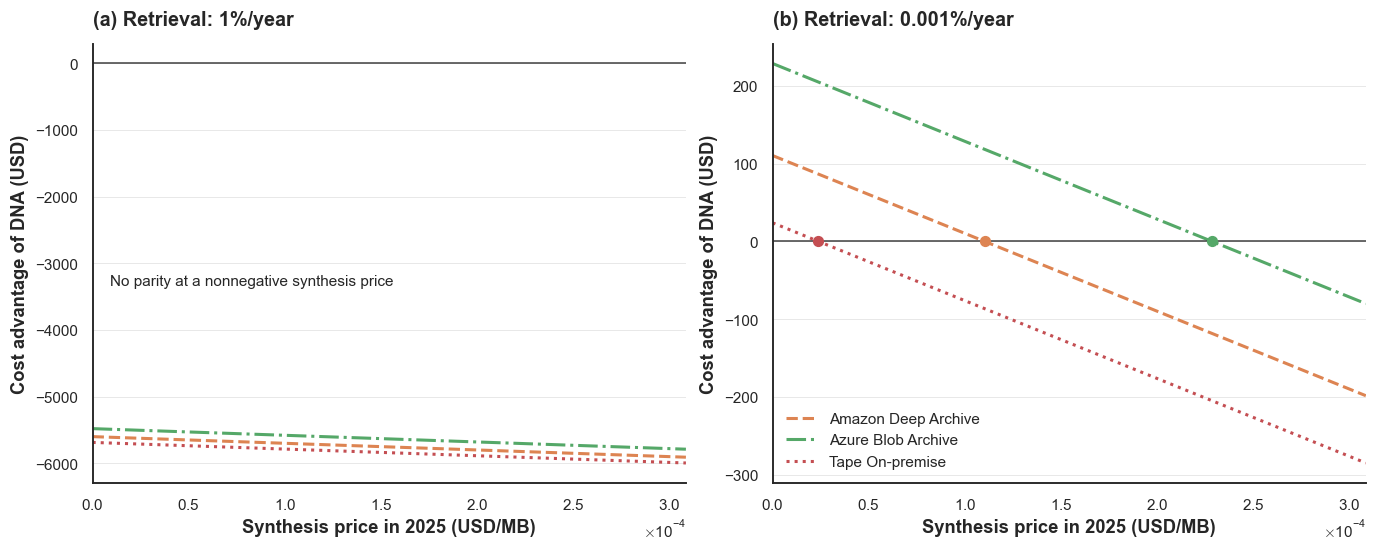

In [4]:
s1_scenarios = {"baseline": BASE, "rare_retrieval": replace(BASE, annual_retrieval_percent=RARE_RETRIEVAL)}
rare_thresholds = threshold_at_start(s1_scenarios["rare_retrieval"])
positive = rare_thresholds.threshold_start_usd_per_mb.dropna()
price_max = float(positive.max() * 1.35) if len(positive) else 0.001
factor = (1 - BASE.synthesis_decline_percent / 100) ** (BASE.start_year - BASE.dna_cost_base_year)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.9), layout="constrained")
curves, crossings = [], []
for index, ((label, scenario), ax) in enumerate(zip(s1_scenarios.items(), axes)):
    for tech in PEERS:
        result = dna_cost_advantage(
            scenario, "dna_synthesis_cost_per_mb", tech, False,
            focus=False, x_range=(0.0, price_max / factor),
        )
        frame = result.curve.copy()
        frame["price_at_start_usd_per_mb"] = frame.parameter_value * factor
        frame["scenario"] = label
        curves.append(frame)
        ax.plot(frame.price_at_start_usd_per_mb, frame.gain_usd,
                label=tech, color=COLORS[tech], ls=STYLES[tech])
        for crossing in result.crossings:
            if crossing.value >= 0:
                price = crossing.value * factor
                ax.scatter(price, 0, color=COLORS[tech], s=40, zorder=5)
                crossings.append({"scenario": label, "technology": tech,
                                  "threshold_start_usd_per_mb": price})
    ax.axhline(0, color="0.25", lw=1)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    ax.set_xlim(0, price_max)
    tidy(ax, f"Synthesis price in {BASE.start_year} (USD/MB)",
         "Cost advantage of DNA (USD)",
         f"({chr(97 + index)}) Retrieval: {scenario.annual_retrieval_percent:g}%/year")
    if label == "baseline" and not threshold_at_start(scenario).reachable.any():
        ax.text(0.03, 0.45, "No parity at a nonnegative synthesis price",
                transform=ax.transAxes, fontsize=10)
legend(axes[1], loc="lower left")
record("S1_synthesis_cost_advantage", fig,
       f"DNA cost advantage over three alternatives, defined as comparator lifecycle cost minus "
       f"DNA lifecycle cost. Baseline: {describe(BASE)}. Panel (b) changes retrieval only to "
       f"{RARE_RETRIEVAL:g}%/year. Positive values favour DNA; dots denote exact nonnegative "
       f"price thresholds. The fitted synthesis price is USD {BASE.dna_synthesis_cost_per_mb:,.2f}/MB "
       f"in {BASE.dna_cost_base_year}, far outside this hypothetical price window. Sequencing and all "
       "other costs remain at their baseline trajectories. No negative-price subsidy is plotted.",
       {"curves": pd.concat(curves, ignore_index=True),
        "crossings": pd.DataFrame(crossings, columns=["scenario", "technology", "threshold_start_usd_per_mb"])},
       s1_scenarios)


## S2 — how retrieval constrains the synthesis break-even price

The vertical axis reports the **maximum nonnegative synthesis price at deployment** that makes total DNA cost equal to the comparator. Higher thresholds mean more room for synthesis cost. Beyond a curve's endpoint, sequencing alone is too expensive. Those missing values are not set to zero or joined across.

Prices are converted from the solver's anchor-year units into the labelled deployment-year units. The marked baseline retrieval remains fixed at 1%/year in both panels.


C:\Users\Alex\AppData\Local\Temp\ipykernel_18280\1613219677.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  s2 = pd.concat(rows, ignore_index=True)


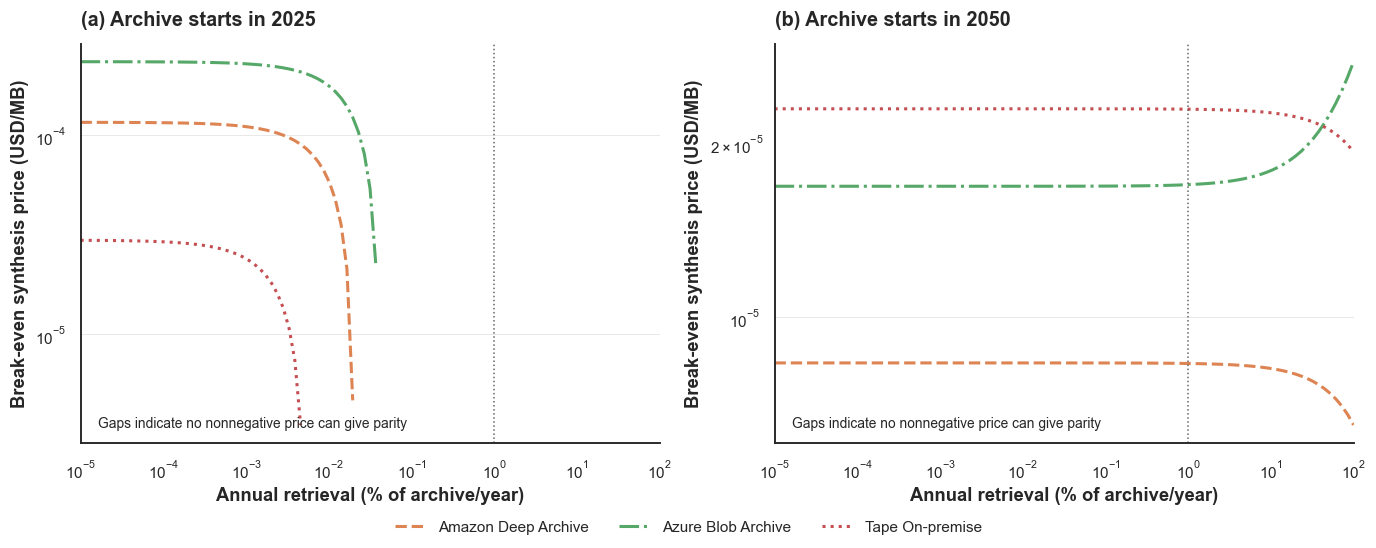

In [5]:
retrieval_grid = np.unique(np.r_[np.geomspace(1e-5, 100, 101), BASE.annual_retrieval_percent, RARE_RETRIEVAL])
s2_scenarios = {"baseline": BASE, "future": replace(BASE, start_year=FUTURE_START)}
rows = []
for label, scenario in s2_scenarios.items():
    for retrieval in retrieval_grid:
        frame = threshold_at_start(replace(scenario, annual_retrieval_percent=float(retrieval)))
        frame["scenario"] = label
        rows.append(frame)
s2 = pd.concat(rows, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.9), layout="constrained")
for index, ((label, scenario), ax) in enumerate(zip(s2_scenarios.items(), axes)):
    for tech in PEERS:
        frame = s2[(s2.scenario == label) & (s2.technology == tech)].sort_values("annual_retrieval_percent")
        ax.plot(frame.annual_retrieval_percent, frame.threshold_start_usd_per_mb,
                color=COLORS[tech], ls=STYLES[tech], label=tech)
    ax.axvline(BASE.annual_retrieval_percent, color="0.4", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlim(retrieval_grid.min(), retrieval_grid.max())
    ax.set_yscale("log")
    tidy(ax, "Annual retrieval (% of archive/year)", "Break-even synthesis price (USD/MB)",
         f"({chr(97 + index)}) Archive starts in {scenario.start_year}")
    ax.text(0.03, 0.04, "Gaps indicate no nonnegative price can give parity",
            transform=ax.transAxes, fontsize=9)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
record("S2_retrieval_vs_synthesis_threshold", fig,
       f"Maximum synthesis price at archive deployment that gives lifecycle cost parity with each "
       f"alternative. Start years are {BASE.start_year} and {FUTURE_START}; annual retrieval is varied "
       f"and the remaining baseline is {describe(BASE)}. The vertical dotted line marks "
       f"{BASE.annual_retrieval_percent:g}% annual retrieval. Each plotted threshold solves the full "
       "lifecycle model; absent values indicate that no nonnegative synthesis price can achieve parity "
       "because sequencing alone exceeds the comparator's total. Both axes are logarithmic.",
       {"thresholds": s2}, s2_scenarios)


## S3 — start-year parity under alternative synthesis declines

Each point represents a **different archive started in that year**, retained for the same duration; it is not the cumulative cost of a single archive aging through time. Only synthesis decline changes. The horizontal parity line is \(C_{\mathrm{DNA}}/C_{\mathrm{comparison}}=1\). Markers indicate the first sampled integer start year at or below parity. No crossing by the last sampled year remains missing in the CSV.

The faster rates below are explicit what-if annual percentages, not extrapolation estimates.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


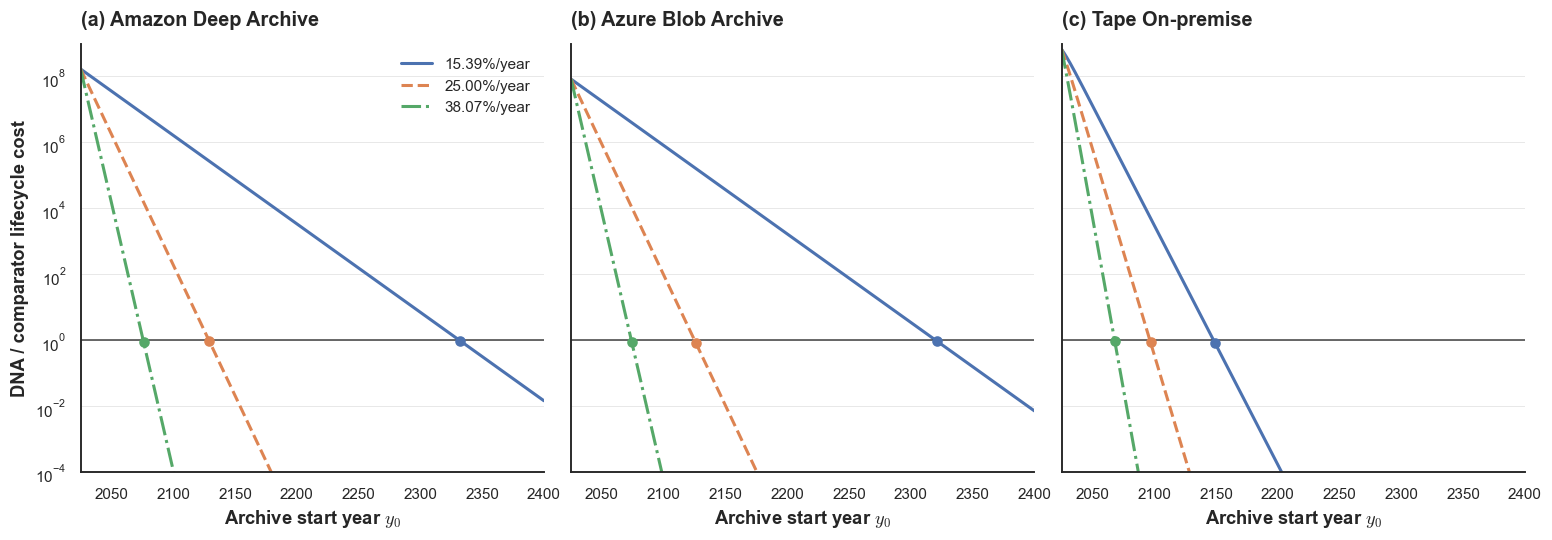

,technology,synthesis_decline_percent,first_integer_start_year_at_parity,search_end
0,Amazon Deep Archive,15.388500,2332,2400
1,Azure Blob Archive,15.388500,2321,2400
2,Tape On-premise,15.388500,2149,2400
3,Amazon Deep Archive,25.000000,2129,2400
4,Azure Blob Archive,25.000000,2126,2400
5,Tape On-premise,25.000000,2097,2400
6,Amazon Deep Archive,38.065945,2076,2400
7,Azure Blob Archive,38.065945,2074,2400
8,Tape On-premise,38.065945,2068,2400


In [6]:
synthesis_rates = [float(BASE.synthesis_decline_percent), 25.0, float(BASE.sequencing_decline_percent)]
s3_scenarios = {f"decline_{rate:.6g}": replace(BASE, synthesis_decline_percent=rate)
                for rate in synthesis_rates}
fig, axes = plt.subplots(1, len(PEERS), figsize=(14, 4.8), sharey=True, layout="constrained")
rows, parity_rows = [], []
for rate_index, (label, scenario) in enumerate(s3_scenarios.items()):
    projection = simulate_start_years(scenario, FINAL_START)
    wide = projection.pivot(index="start_year", columns="technology", values="total_cost_usd")
    for ax, tech in zip(axes, PEERS):
        ratio = wide["DNA"] / wide[tech]
        eligible = ratio.index[ratio <= 1]
        crossing = int(eligible[0]) if len(eligible) else None
        ax.plot(ratio.index, ratio, color=PALETTE[rate_index],
                ls=("-", "--", "-.")[rate_index],
                label=f"{scenario.synthesis_decline_percent:.2f}%/year")
        if crossing is not None:
            ax.scatter(crossing, ratio.loc[crossing], color=PALETTE[rate_index], s=35, zorder=5)
        rows.append(pd.DataFrame({"start_year": ratio.index, "technology": tech,
                                  "synthesis_decline_percent": scenario.synthesis_decline_percent,
                                  "dna_cost_usd": wide["DNA"].to_numpy(),
                                  "comparison_cost_usd": wide[tech].to_numpy(),
                                  "cost_ratio": ratio.to_numpy()}))
        parity_rows.append({"technology": tech, "synthesis_decline_percent": scenario.synthesis_decline_percent,
                            "first_integer_start_year_at_parity": crossing, "search_end": FINAL_START})
for index, (ax, tech) in enumerate(zip(axes, PEERS)):
    ax.axhline(1, color="0.25", lw=1)
    ax.set_yscale("log")
    ax.set_xlim(BASE.start_year, FINAL_START)
    # Restrict the display to economically interpretable ratios; full tails stay in CSV.
    ax.set_ylim(1e-4, 1e9)
    tidy(ax, r"Archive start year $y_0$", "DNA / comparator lifecycle cost" if index == 0 else None,
         f"({chr(97 + index)}) {tech}")
legend(axes[0], loc="upper right")
s3_parity = pd.DataFrame(parity_rows)
record("S3_start_year_decline_scenarios", fig,
       f"DNA-to-comparator lifecycle cost ratios for different archive start years under three "
       f"synthesis-decline assumptions, stated as actual annual percentages. Workload and retention: "
       f"{describe(BASE)}. Sequencing decline remains {BASE.sequencing_decline_percent:.2f}%/year. "
       "Each point is a new archive deployment; the horizontal line is parity. Dots mark the first "
       f"integer start year reaching parity through {FINAL_START}; these are conditional scenario "
       "results, not calendar forecasts. Ratios outside the plotted range remain in the CSV.",
       {"ratios": pd.concat(rows, ignore_index=True), "parity_years": s3_parity}, s3_scenarios)
display(s3_parity)


## S4 — joint sensitivity to DNA and cloud cost declines

The colour is \(\log_{10}(C_{\mathrm{DNA}}/C_{\mathrm{Amazon}})\), evaluated for a future deployment. White is parity, red means DNA costs more, and blue means DNA costs less. The black contour marks parity when it is present.

Both decline assumptions affect all relevant years from their original fixed price anchors. These are equally spaced parameter sweeps, **not** probabilities.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


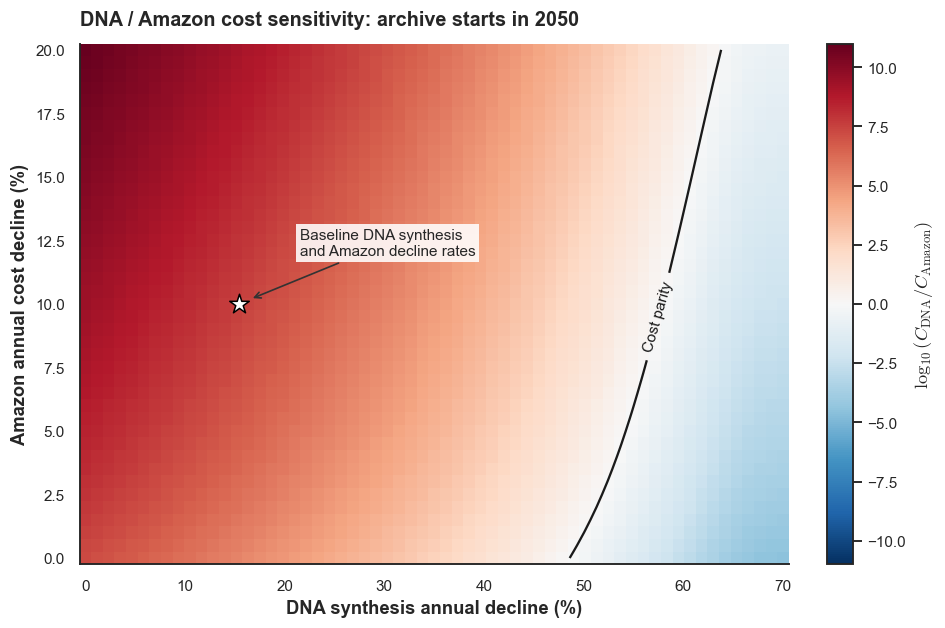

In [7]:
s4_scenario = replace(BASE, start_year=FUTURE_START, technologies=("DNA", COMPARATOR))
dna_rates = np.linspace(0, 70, 61)
cloud_rates = np.linspace(0, 20, 41)
rows = []
for cloud_rate in cloud_rates:
    for dna_rate in dna_rates:
        probe = replace(s4_scenario, synthesis_decline_percent=float(dna_rate),
                        amazon_decline_percent=float(cloud_rate))
        costs = totals(probe)
        rows.append({"synthesis_decline_percent": dna_rate, "amazon_decline_percent": cloud_rate,
                     "dna_cost_usd": costs["DNA"], "comparison_cost_usd": costs[COMPARATOR],
                     "log10_cost_ratio": np.log10(costs["DNA"] / costs[COMPARATOR])})
s4 = pd.DataFrame(rows)
z = s4.pivot(index="amazon_decline_percent", columns="synthesis_decline_percent",
             values="log10_cost_ratio").to_numpy()
limit = float(np.ceil(np.max(np.abs(z))))
fig, ax = plt.subplots(figsize=(8.5, 5.6), layout="constrained")
mesh = ax.pcolormesh(dna_rates, cloud_rates, z, shading="auto", cmap="RdBu_r",
                     norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit), rasterized=True)
if z.min() <= 0 <= z.max():
    contour = ax.contour(dna_rates, cloud_rates, z, levels=[0], colors="0.1", linewidths=1.5)
    ax.clabel(contour, fmt={0: "Cost parity"}, fontsize=10)
ax.scatter(BASE.synthesis_decline_percent, BASE.amazon_decline_percent,
           marker="*", s=180, color="white", edgecolor="black", zorder=5)
ax.annotate(
    "Baseline DNA synthesis\nand Amazon decline rates",
    (BASE.synthesis_decline_percent, BASE.amazon_decline_percent),
    xytext=(40, 30), textcoords="offset points", ha="left", va="bottom",
    fontsize=10, zorder=6,
    arrowprops={"arrowstyle": "->", "color": "0.2", "lw": 1.1, "shrinkB": 10},
    bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "none", "pad": 2.5},
)
tidy(ax, "DNA synthesis annual decline (%)", "Amazon annual cost decline (%)",
     f"DNA / Amazon cost sensitivity: archive starts in {FUTURE_START}")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$\log_{10}(C_{\mathrm{DNA}}/C_{\mathrm{Amazon}})$")
record("S4_joint_decline_sensitivity", fig,
       f"Joint sensitivity of DNA versus Amazon Deep Archive lifecycle cost, for {describe(s4_scenario)}. "
       "The synthesis decline varies from 0 to 70%/year; all Amazon tariff components share a "
       "decline varied from 0 to 20%/year. Colour gives the base-10 log cost ratio: negative values "
       "favour DNA and positive values favour Amazon. A black contour marks parity; the star marks "
       "the baseline rates. Price anchors are held fixed, and sequencing follows its baseline trajectory. "
       "This grid is a scenario sweep, not a probability distribution.",
       {"grid": s4}, {"future": s4_scenario})


## S5 — discounting and the affordable synthesis price

These plots use **present value**, discounting annual costs back to each archive's deployment year. Both panels use rare retrieval (0.001%/year) to allow nonnegative synthesis thresholds, comparing deployments in the baseline and future start years. A larger discount rate discounts ongoing storage bills more than DNA's up-front synthesis, often lowering the affordable synthesis price. Discounting is distinct from technological cost decline.


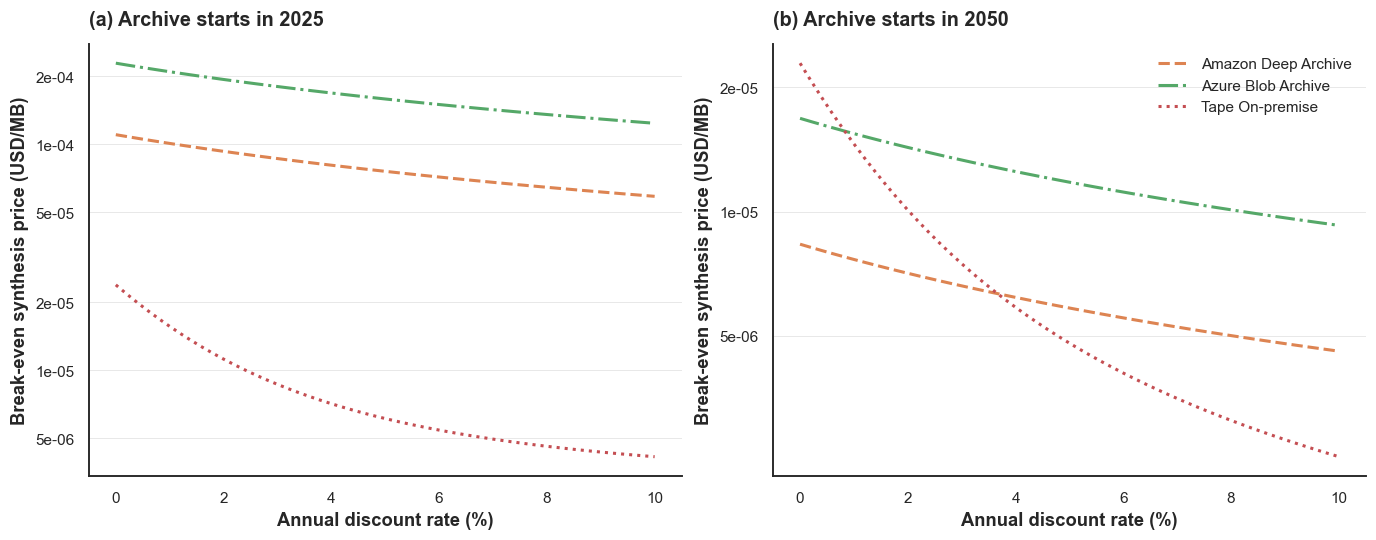

In [8]:
s5_scenarios = {
    "baseline": replace(BASE, annual_retrieval_percent=RARE_RETRIEVAL),
    "future": replace(BASE, start_year=FUTURE_START, annual_retrieval_percent=RARE_RETRIEVAL),
}
rows = []
for label, scenario in s5_scenarios.items():
    for rate in np.linspace(0, 10, 51):
        probe = replace(scenario, discount_rate_percent=float(rate))
        frame = threshold_at_start(probe, present_value=True)
        frame["discount_rate_percent"] = rate
        frame["scenario"] = label
        rows.append(frame)
s5 = pd.concat(rows, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), layout="constrained")
for index, ((label, scenario), ax) in enumerate(zip(s5_scenarios.items(), axes)):
    for tech in PEERS:
        frame = s5[(s5.scenario == label) & (s5.technology == tech)]
        ax.plot(frame.discount_rate_percent, frame.threshold_start_usd_per_mb,
                color=COLORS[tech], ls=STYLES[tech], label=tech)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0e}"))
    tidy(ax, "Annual discount rate (%)", "Break-even synthesis price (USD/MB)",
         f"({chr(97 + index)}) Archive starts in {scenario.start_year}")
legend(axes[1], loc="upper right")
record("S5_discounting_synthesis_threshold", fig,
       f"Effect of discounting on the deployment-year synthesis price that gives present-value "
       f"parity with each alternative. Archives start in {BASE.start_year} and {FUTURE_START}; "
       f"retrieval is {RARE_RETRIEVAL:g}%/year in both panels. "
       f"Retention is {BASE.horizon_years} years. The price threshold is in USD/MB in the deployment "
       "year. Annual costs are discounted to that year's beginning, with the initial synthesis "
       "charged at time zero. All technological decline rates remain fixed; missing thresholds "
       "indicate no parity at a nonnegative synthesis price.",
       {"thresholds": s5}, s5_scenarios)


## S6 — when DNA durability matters

Durability is an integer number of years. The plateau starts when durability reaches the retention period: there are then no replacements. Shorter durability may cause additional synthesis writes, producing steps.

The baseline synthesis decline makes distant replacement writes cheap. A second, explicitly labelled **zero-synthesis-decline** scenario isolates how that assumption changes the value of durability. Each curve is normalized to its own no-replacement cost; this is not a comparison of absolute costs between scenarios.


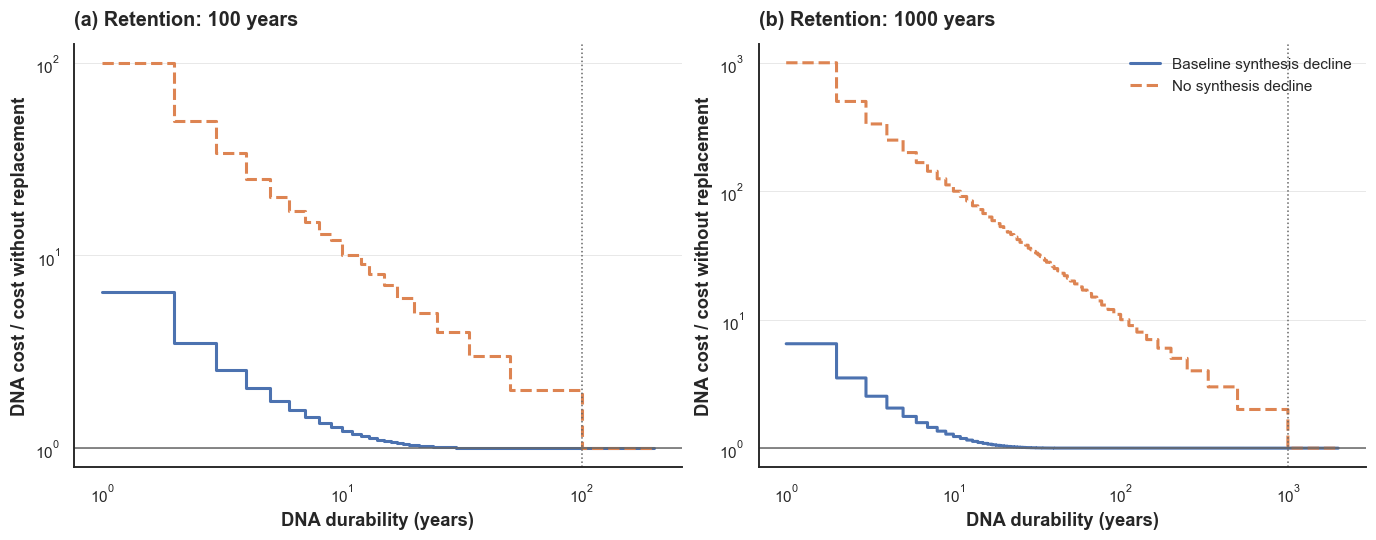

In [9]:
durability_grid = np.arange(1, min(1000, BASE.horizon_years * 2) + 1)
horizons = [BASE.horizon_years, 1000]
s6_scenarios = {
    "Baseline synthesis decline": BASE,
    "No synthesis decline": replace(BASE, synthesis_decline_percent=0.0),
}
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), layout="constrained")
rows = []
for index, (horizon, ax) in enumerate(zip(horizons, axes)):
    grid = np.unique(np.r_[durability_grid, np.arange(1, horizon * 2 + 1)])
    for curve_index, (label, scenario) in enumerate(s6_scenarios.items()):
        no_replacement = replace(scenario, horizon_years=horizon, dna_durability_years=horizon,
                                 technologies=("DNA",))
        # Evaluate potential writes once with the public engine, then select
        # the integer replacement schedule for each durability.
        annual = simulate_scenario(replace(no_replacement, dna_durability_years=1)).yearly
        potential_writes = annual.write_cost_usd.to_numpy()
        other_cost = float(annual[["read_cost_usd", "maintenance_cost_usd"]].to_numpy().sum())
        reference = float(potential_writes[0] + other_cost)
        values = []
        for durability in grid:
            probe = replace(no_replacement, dna_durability_years=int(durability))
            cost = float(potential_writes[::int(durability)].sum() + other_cost)
            values.append(cost / reference)
            rows.append({"horizon_years": horizon, "durability_years": int(durability),
                         "scenario": label, "synthesis_decline_percent": probe.synthesis_decline_percent,
                         "dna_cost_usd": cost, "no_replacement_cost_usd": reference,
                         "relative_cost": cost / reference,
                         "replacement_count": (horizon - 1) // int(durability)})
        ax.step(grid, values, where="post", color=PALETTE[curve_index],
                ls=("-", "--")[curve_index], label=label)
    ax.axvline(horizon, color="0.4", ls=":", lw=1)
    ax.axhline(1, color="0.4", lw=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    tidy(ax, "DNA durability (years)", "DNA cost / cost without replacement",
         f"({chr(97 + index)}) Retention: {horizon} years")
legend(axes[1], loc="upper right")
record("S6_durability_and_replacements", fig,
       f"DNA lifecycle cost relative to the same scenario without replacement, as durability varies "
       f"in whole years. The archive starts in {BASE.start_year}. Retention is {horizons[0]} years "
       f"in (a) and {horizons[1]} years in (b). Curves compare the baseline synthesis decline "
       f"({BASE.synthesis_decline_percent:.2f}%/year) with zero synthesis decline; sequencing is unchanged. "
       "Each curve has its own no-replacement denominator. Replacement occurs at integer multiples "
       "of durability strictly before the end of the horizon. Vertical dotted lines mark durability "
       "equal to retention; longer durability has no further cost effect in this model.",
       {"durability": pd.DataFrame(rows)}, s6_scenarios)


## S7 — robustness to a nonzero synthesis-cost floor

This is the one extension calculated inside this notebook: replace each year's synthesis price by
\[
p_{\rm synth}(y)=\max\{p_{\rm anchor}(1-r_{\rm synth})^{y-y_{\rm anchor}},\ p_{\min}\}.
\]
All other calculations use the calculator's workload, sequencing, replacement, and tariff conventions. The floor is in **USD per MB**, held constant over calendar time. It is not USD per nucleotide.

The logarithmic plots show total DNA/comparator lifecycle ratios for independently started archives. Nonzero floors can delay or eliminate parity, or make DNA lose an earlier advantage as comparator prices continue falling. A first crossing is therefore not proof of lasting competitiveness. Floor levels are illustrative stress tests, not empirical lower-bound estimates.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


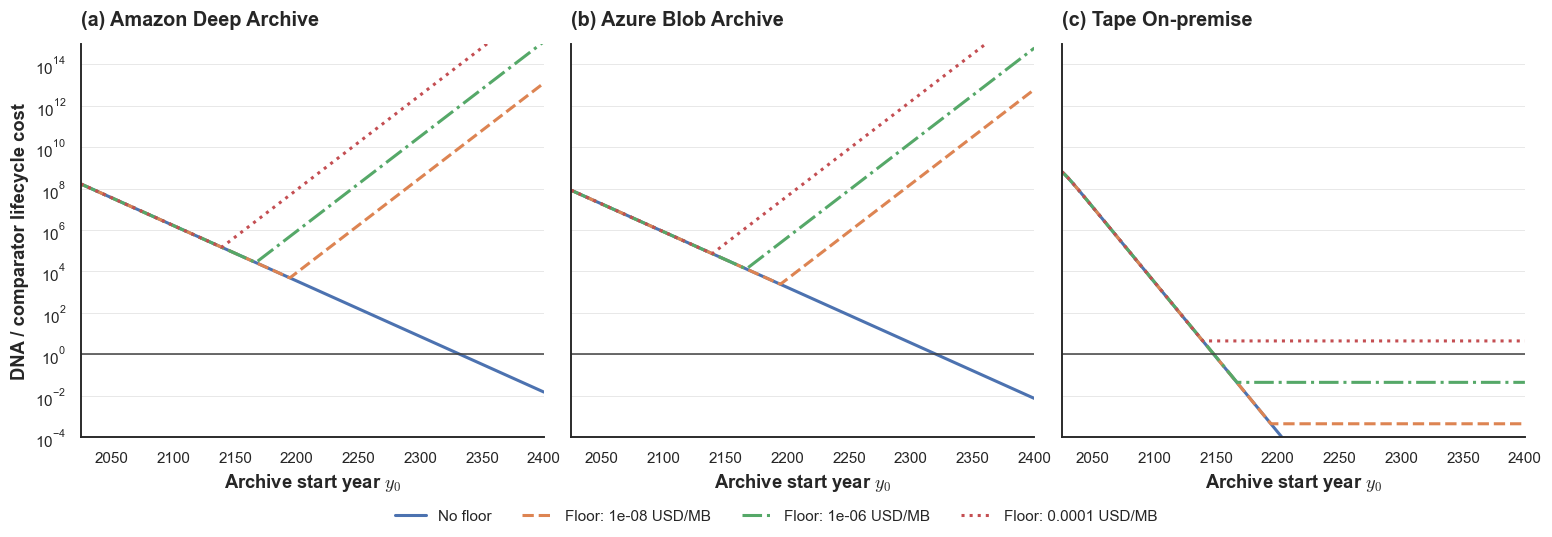

In [10]:
floor_values = [0.0, 1e-8, 1e-6, 1e-4]  # USD/MB; hypothetical, editable
start_years = np.arange(BASE.start_year, FINAL_START + 1)
reference = simulate_start_years(BASE, FINAL_START).pivot(
    index="start_year", columns="technology", values="total_cost_usd")
fig, axes = plt.subplots(1, len(PEERS), figsize=(14, 4.8), sharey=True, layout="constrained")
rows = []
for floor_index, floor in enumerate(floor_values):
    dna_cost = np.array([dna_cost_with_floor(replace(BASE, start_year=int(year)), floor)
                         for year in start_years])
    for ax, tech in zip(axes, PEERS):
        ratio = dna_cost / reference.loc[start_years, tech].to_numpy()
        label = "No floor" if floor == 0 else f"Floor: {floor:g} USD/MB"
        ax.plot(start_years, ratio, color=PALETTE[floor_index],
                ls=("-", "--", "-.", ":")[floor_index], label=label)
        rows.append(pd.DataFrame({"start_year": start_years, "technology": tech,
                                  "floor_usd_per_mb": floor, "dna_cost_usd": dna_cost,
                                  "comparison_cost_usd": reference.loc[start_years, tech].to_numpy(),
                                  "cost_ratio": ratio}))
for index, (ax, tech) in enumerate(zip(axes, PEERS)):
    ax.axhline(1, color="0.25", lw=1)
    ax.set_yscale("log")
    ax.set_xlim(BASE.start_year, FINAL_START)
    ax.set_ylim(1e-4, 1e15)
    tidy(ax, r"Archive start year $y_0$", "DNA / comparator lifecycle cost" if index == 0 else None,
         f"({chr(97 + index)}) {tech}")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=4, frameon=False)
record("S7_synthesis_cost_floor", fig,
       f"Effect of illustrative synthesis-price floors on DNA/comparator lifecycle cost ratios for "
       f"independent archive deployments from {BASE.start_year} through {FINAL_START}. Other settings: "
       f"{describe(BASE)}. Each synthesis price is the larger of the baseline declining price and "
       "the fixed floor (USD/MB), including replacement writes. The horizontal line denotes parity. "
       "Floor levels are sensitivity assumptions, not measured technology limits. Comparator prices "
       "continue to decline under their baseline models. Ratios outside the displayed range are "
       "retained in the CSV; an initial parity crossing need not persist.",
       {"ratios": pd.concat(rows, ignore_index=True)}, {"baseline": BASE})


## S8 — sequencing decline versus Amazon decline

This replaces the **synthesis-decline horizontal axis of S4 with sequencing decline**. Both panels use the same archive and fixed deployment year as S4. Panel (a) holds synthesis at its baseline decline; panel (b) uses the explicitly hypothetical 60% annual synthesis decline set by `HEATMAP_SYNTHESIS_DECLINE`.

At the baseline synthesis trajectory, even free sequencing cannot overcome the up-front write cost in this range, so **no break-even line exists**. The conditional panel shows where faster sequencing can make DNA competitive once synthesis is sufficiently inexpensive. All DNA prices remain anchored in 2025; the conditional scenario is not a measured trend.

The black boundary is solved numerically for actual cost equality, not inferred from colours. Missing roots remain absent. Both panels share a symmetric colour scale and S4's sign convention: blue favours DNA; red favours Amazon. The star shows baseline sequencing and Amazon declines within each panel, not necessarily the original full baseline.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


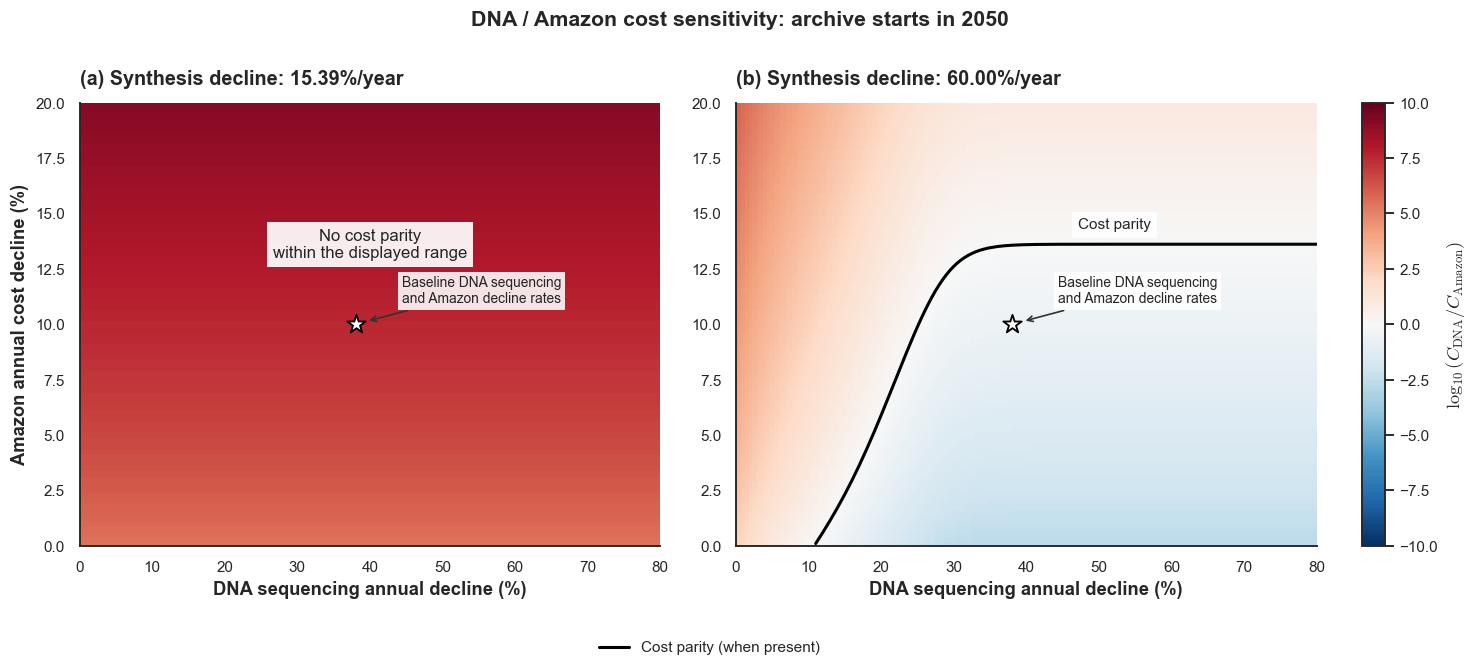

scenario
accelerated_synthesis    139
baseline_synthesis         0
Name: Number of solved parity points, dtype: int64

In [11]:
s8_scenarios = {
    "baseline_synthesis": replace(BASE, start_year=FUTURE_START,
                                 technologies=("DNA", "Amazon Deep Archive")),
    "accelerated_synthesis": replace(BASE, start_year=FUTURE_START,
                                    synthesis_decline_percent=HEATMAP_SYNTHESIS_DECLINE,
                                    technologies=("DNA", "Amazon Deep Archive")),
}
sequencing_grid = np.linspace(0, 80, 161)
s8_cloud_grid = np.linspace(0, 20, 81)
grid_frames, root_rows = [], []
for key, scenario in s8_scenarios.items():
    _, _, dna_total, cloud_total = heatmap_evaluator(scenario, scenario.horizon_years)
    dna_costs = np.array([dna_total(rate, scenario.horizon_years) for rate in sequencing_grid])
    for cloud_rate in s8_cloud_grid:
        peer = cloud_total(cloud_rate, scenario.horizon_years)
        grid_frames.append(pd.DataFrame({
            "scenario": key, "sequencing_decline_percent": sequencing_grid,
            "amazon_decline_percent": cloud_rate, "dna_cost_usd": dna_costs,
            "comparison_cost_usd": peer, "log10_cost_ratio": np.log10(dna_costs / peer),
        }))
    # Solve along each x coordinate, retaining the near-horizontal asymptote.
    for sequencing_rate, dna_cost in zip(sequencing_grid, dna_costs):
        rate = parity_root(
            lambda r: dna_cost - cloud_total(r, scenario.horizon_years),
            float(s8_cloud_grid.min()), float(s8_cloud_grid.max()),
        )
        root_rows.append({
            "scenario": key, "sequencing_decline_percent": sequencing_rate,
            "amazon_decline_percent": rate, "dna_cost_usd": dna_cost,
            "comparison_cost_usd": cloud_total(rate, scenario.horizon_years) if np.isfinite(rate) else np.nan,
            "root_exists": bool(np.isfinite(rate)),
        })
s8 = pd.concat(grid_frames, ignore_index=True)
s8_boundaries = pd.DataFrame(root_rows)
fig = joint_heatmap_panels(
    s8, s8_boundaries, s8_scenarios, "sequencing_decline_percent",
    "DNA sequencing annual decline (%)", BASE.sequencing_decline_percent,
)
record("S8_sequencing_decline_sensitivity", fig,
       f"Joint sensitivity to DNA sequencing and Amazon tariff decline, for an archive starting in "
       f"{FUTURE_START}. Workload: {describe(s8_scenarios['baseline_synthesis'])}. "
       f"Synthesis decline is fixed at {BASE.synthesis_decline_percent:.2f}%/year in (a) and at an "
       f"illustrative {HEATMAP_SYNTHESIS_DECLINE:g}%/year in (b), with the same DNA price anchor. "
       "Sequencing decline spans 0–80%/year and Amazon decline 0–20%/year. "
       "Black lines denote numerically solved lifecycle cost equality; absent lines mean no root "
       "within the displayed range. Colour is the log cost ratio, using a common symmetric scale; "
       "negative values favour DNA. Stars mark baseline sequencing and Amazon inputs. The second "
       "panel is conditional on accelerated synthesis, not a forecast.",
       {"grid": s8, "parity_boundary": s8_boundaries}, s8_scenarios)
display(s8_boundaries.groupby("scenario").root_exists.sum().rename("Number of solved parity points"))


## S9 — retention years versus Amazon decline

This replaces S4's horizontal axis with the **retention period**, keeping the deployment year fixed. The horizontal axis is logarithmic and every evaluated retention period is a whole number of years. The panels use the same two synthesis scenarios as S8; sequencing follows its baseline trajectory.

The black line solves for the Amazon annual decline giving cost equality at each sampled integer retention. Thus the line is a boundary between regions, not a claim that fractional retention years were simulated. Lines join sampled solutions for visual guidance; exact roots and integer horizons are exported.

Increasing retention does not guarantee parity: when future tariffs keep declining, their accumulated cost can approach a finite limit. DNA replacement writes are included every 1,000 years, strictly before the retention endpoint. The baseline panel retains its genuine no-parity result through 10,000 years.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


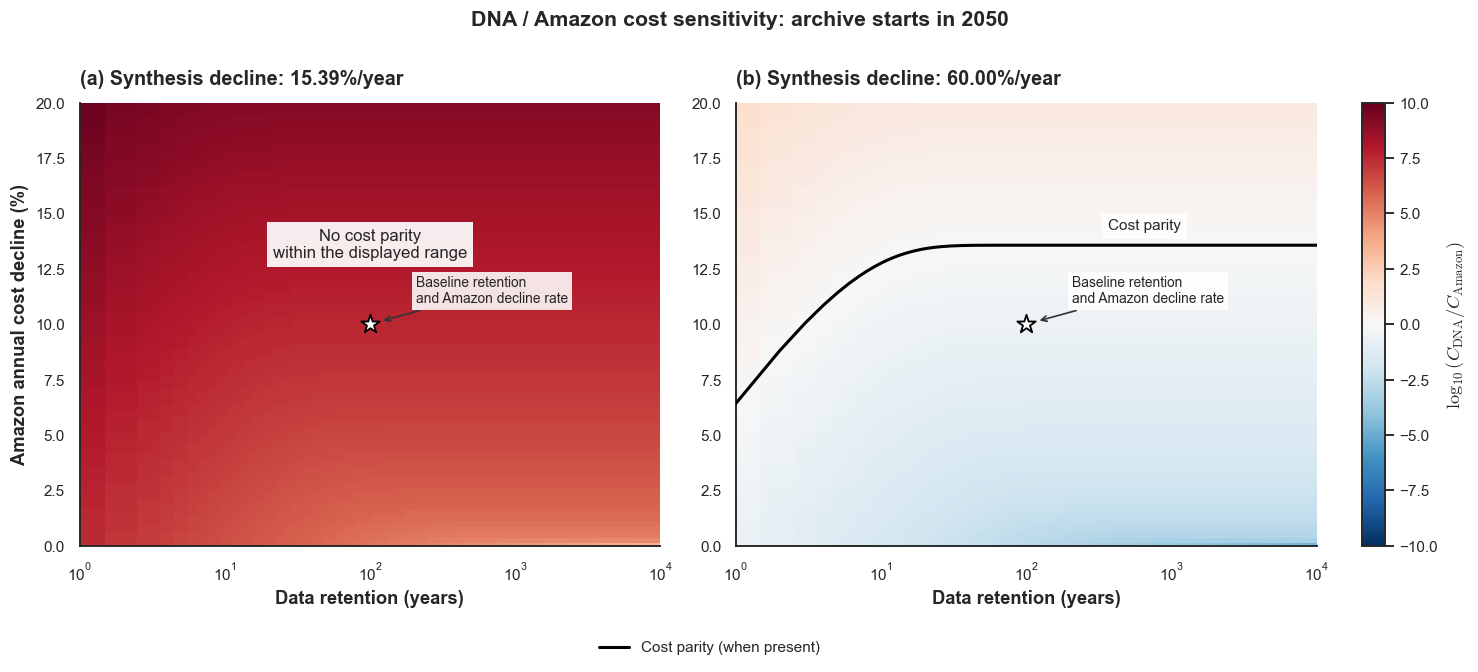

scenario
accelerated_synthesis    156
baseline_synthesis         0
Name: Number of solved parity points, dtype: int64

In [12]:
s9_scenarios = {
    "baseline_synthesis": replace(BASE, start_year=FUTURE_START,
                                 technologies=("DNA", "Amazon Deep Archive")),
    "accelerated_synthesis": replace(BASE, start_year=FUTURE_START,
                                    synthesis_decline_percent=HEATMAP_SYNTHESIS_DECLINE,
                                    technologies=("DNA", "Amazon Deep Archive")),
}
retention_grid = np.unique(np.r_[
    np.round(np.geomspace(1, HEATMAP_MAX_RETENTION, 201)).astype(int),
    BASE.horizon_years, BASE.dna_durability_years,
    BASE.dna_durability_years + 1,
])
retention_grid = retention_grid[(retention_grid >= 1) & (retention_grid <= HEATMAP_MAX_RETENTION)]
s9_cloud_grid = np.linspace(0, 20, 81)
grid_frames, root_rows = [], []
for key, scenario in s9_scenarios.items():
    dna_cumulative, cloud_cumulative, dna_total, cloud_total = heatmap_evaluator(
        scenario, int(retention_grid.max()))
    dna_costs = dna_cumulative(scenario.sequencing_decline_percent)[retention_grid - 1]
    for cloud_rate in s9_cloud_grid:
        peer = cloud_cumulative(cloud_rate)[retention_grid - 1]
        grid_frames.append(pd.DataFrame({
            "scenario": key, "retention_years": retention_grid,
            "amazon_decline_percent": cloud_rate, "dna_cost_usd": dna_costs,
            "comparison_cost_usd": peer, "log10_cost_ratio": np.log10(dna_costs / peer),
        }))
    for horizon, dna_cost in zip(retention_grid, dna_costs):
        rate = parity_root(
            lambda r: dna_cost - cloud_total(r, int(horizon)),
            float(s9_cloud_grid.min()), float(s9_cloud_grid.max()),
        )
        root_rows.append({
            "scenario": key, "retention_years": int(horizon), "amazon_decline_percent": rate,
            "dna_cost_usd": dna_cost,
            "comparison_cost_usd": cloud_total(rate, int(horizon)) if np.isfinite(rate) else np.nan,
            "root_exists": bool(np.isfinite(rate)),
        })
s9 = pd.concat(grid_frames, ignore_index=True)
s9_boundaries = pd.DataFrame(root_rows)
fig = joint_heatmap_panels(
    s9, s9_boundaries, s9_scenarios, "retention_years",
    "Data retention (years)", BASE.horizon_years, log_x=True,
)
record("S9_retention_decline_sensitivity", fig,
       f"Joint sensitivity to data retention and Amazon annual tariff decline, for archives deployed "
       f"in {FUTURE_START}. The archive is {BASE.archive_size_tb:g} TB, with "
       f"{BASE.average_asset_size_mb:g} MB/object and {BASE.annual_retrieval_percent:g}% annual retrieval; retention varies "
       f"from 1 to {HEATMAP_MAX_RETENTION:,} whole years. Synthesis decline is "
       f"{BASE.synthesis_decline_percent:.2f}%/year in (a) and an illustrative "
       f"{HEATMAP_SYNTHESIS_DECLINE:g}%/year in (b); sequencing decline stays at "
       f"{BASE.sequencing_decline_percent:.2f}%/year. Both panels share the same log cost-ratio "
       "colour scale. Black boundaries solve for Amazon decline giving exact cost equality at each "
       "sampled integer retention; connecting lines guide the eye. Stars mark baseline retention and "
       "Amazon decline. Initial writes, annual reads, storage costs, and DNA replacement writes are "
       "included. No parity line is drawn where no solution exists in the sampled parameter domain.",
       {"grid": s9, "parity_boundary": s9_boundaries}, s9_scenarios)
display(s9_boundaries.groupby("scenario").root_exists.sum().rename("Number of solved parity points"))


## S10 — sequencing break-even curves for several synthesis declines

A line-only companion to S8. Each curve fixes the annual synthesis decline at **50%, 55%, 60%, or 65%** and solves for the Amazon annual decline that makes DNA's lifecycle cost equal to Amazon's as sequencing decline varies. These are illustrative scenarios, not empirical estimates.

Amazon decline spans **0–30%/year**, extending S8's 0–20% range so the faster-synthesis scenarios fit. At a given sequencing decline, **below a curve DNA is cheaper; above it Amazon is cheaper**. Missing segments indicate no equality within the displayed range; the CSV distinguishes DNA being more expensive everywhere from being cheaper everywhere. The baseline synthesis scenario is evaluated too and explicitly noted when it has no parity.

The star marks baseline sequencing and Amazon inputs; it does not select one synthesis scenario. Run the setup and helper cells first; this figure is otherwise independent of S8.

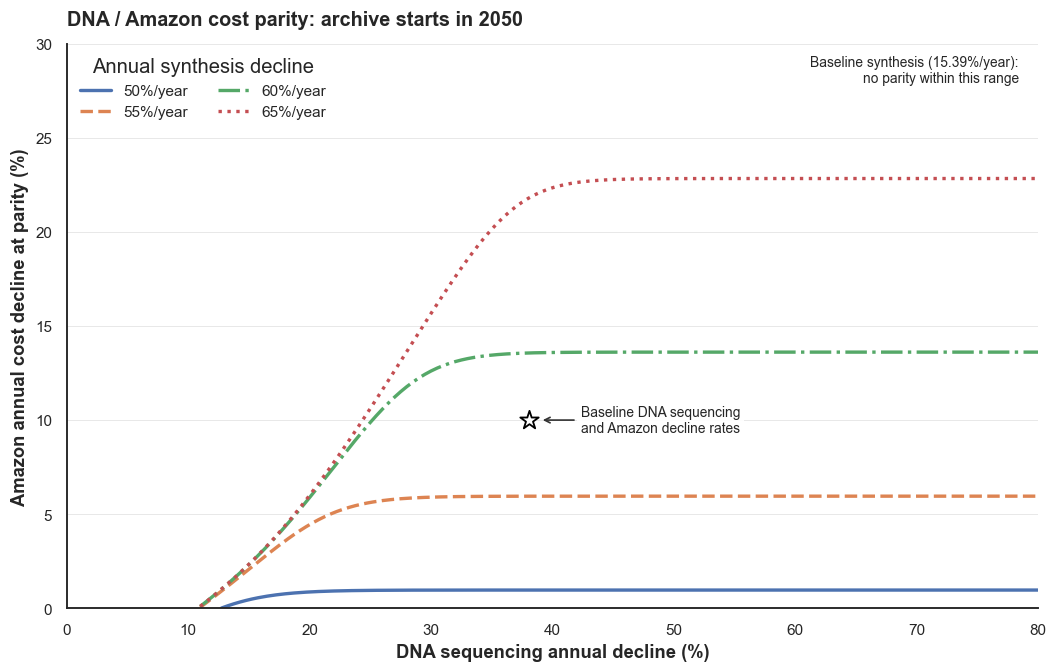

synthesis_decline_percent
15.3885      0
50.0000    270
55.0000    277
60.0000    277
65.0000    277
Name: Solved parity points, dtype: int64

In [13]:
s10_x = np.linspace(0, 80, 321)
s10, s10_scenarios = synthesis_parity_lines("sequencing", s10_x)
fig = plot_synthesis_parity_lines(s10, "sequencing")
record("S10_sequencing_parity_by_synthesis", fig,
       f"Lifecycle cost parity between DNA and Amazon Deep Archive as a function of sequencing decline, "
       f"for archives starting in {FUTURE_START}. Workload: {BASE.archive_size_tb:g} TB; "
       f"{BASE.average_asset_size_mb:g} MB/object; {BASE.annual_retrieval_percent:g}% retrieval/year; "
       f"{BASE.horizon_years} years; no discounting. Each curve fixes synthesis decline at one of "
       f"{', '.join(f'{rate:g}%' for rate in PARITY_SYNTHESIS_RATES)} per year. "
       "The vertical coordinate is the numerically solved Amazon decline giving equal total costs. "
       "Below a curve DNA is cheaper; above it Amazon is cheaper. The Amazon search domain is "
       f"{PARITY_AMAZON_RANGE[0]:g}–{PARITY_AMAZON_RANGE[1]:g}%/year. Missing curve segments have no "
       "parity in this domain. The baseline synthesis scenario is also evaluated. The star marks "
       "baseline sequencing and Amazon inputs, irrespective of synthesis scenario. "
       "All DNA price anchors remain fixed; accelerated synthesis rates are illustrative assumptions.",
       {"parity_boundary": s10}, s10_scenarios)
display(s10.groupby("synthesis_decline_percent").root_exists.sum().rename("Solved parity points"))


## S11 — retention break-even curves for several synthesis declines

A line-only companion to S9 using the same synthesis scenarios and colours as S10. Sequencing follows its baseline trajectory; each curve solves for Amazon decline at equal lifecycle cost as **integer retention years** vary from 1 to 10,000 on a logarithmic axis.

At a fixed retention, **below a curve DNA is cheaper; above it Amazon is cheaper**. The curves can approach a plateau because future cloud costs decline. DNA replacement writes are included at the model's durability intervals. Lines join solved integer-retention points for visual guidance and never substitute a fractional horizon into the model.

The star marks baseline retention and Amazon decline, not a synthesis scenario. Run the setup and helper cells first; this figure is otherwise independent of S9 and S10.

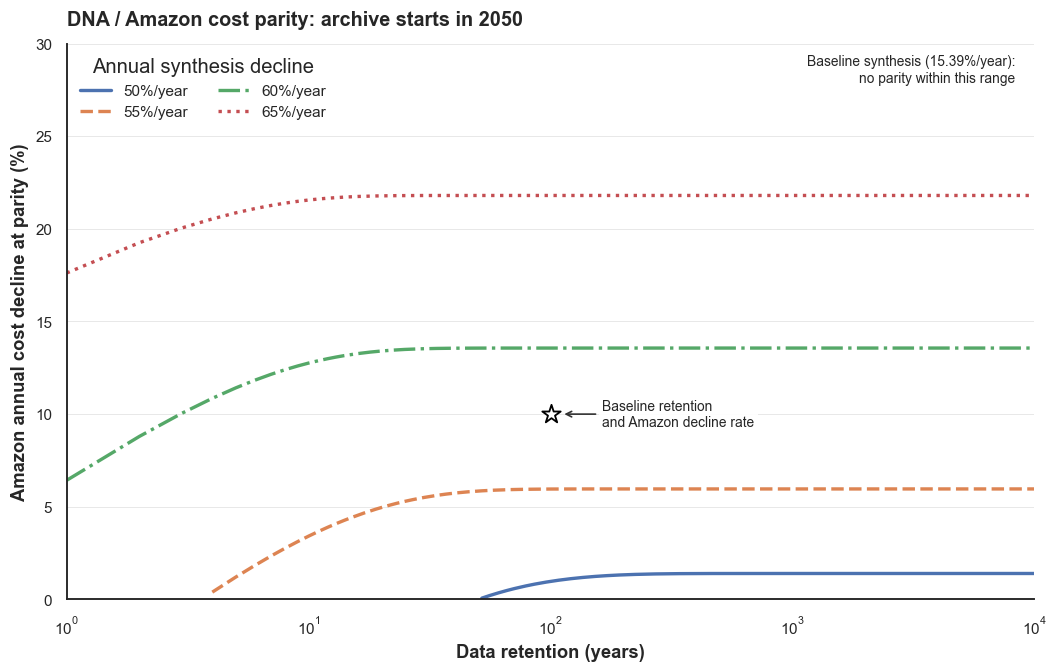

synthesis_decline_percent
15.3885      0
50.0000    139
55.0000    179
60.0000    182
65.0000    182
Name: Solved parity points, dtype: int64

In [14]:
s11_x = np.unique(np.r_[
    np.round(np.geomspace(1, HEATMAP_MAX_RETENTION, 241)).astype(int),
    BASE.horizon_years, BASE.dna_durability_years, BASE.dna_durability_years + 1,
])
s11_x = s11_x[(s11_x >= 1) & (s11_x <= HEATMAP_MAX_RETENTION)]
s11, s11_scenarios = synthesis_parity_lines("retention", s11_x)
fig = plot_synthesis_parity_lines(s11, "retention")
record("S11_retention_parity_by_synthesis", fig,
       f"Lifecycle cost parity between DNA and Amazon Deep Archive as a function of retention, "
       f"for archives deployed in {FUTURE_START}. The archive is {BASE.archive_size_tb:g} TB with "
       f"{BASE.average_asset_size_mb:g} MB/object and {BASE.annual_retrieval_percent:g}% retrieval/year. "
       f"Synthesis declines are {', '.join(f'{rate:g}%' for rate in PARITY_SYNTHESIS_RATES)} per year; "
       f"sequencing decline remains {BASE.sequencing_decline_percent:.2f}%/year. There is no discounting. "
       f"Retention ranges from 1 to {HEATMAP_MAX_RETENTION:,} whole years; replacement writes are included. "
       "Each line gives the Amazon annual decline at exact cost equality for sampled integer "
       "retentions; the connecting lines guide the eye. Below each curve DNA is cheaper; above it "
       "Amazon is cheaper. Missing segments indicate no equality in the "
       f"{PARITY_AMAZON_RANGE[0]:g}–{PARITY_AMAZON_RANGE[1]:g}% Amazon-decline range. The baseline synthesis "
       "case is also evaluated. The star marks baseline retention and Amazon decline. "
       "The accelerated synthesis rates are illustrative, with fixed price anchors.",
       {"parity_boundary": s11}, s11_scenarios)
display(s11.groupby("synthesis_decline_percent").root_exists.sum().rename("Solved parity points"))


## Numerical checks

These checks compare plotted thresholds with full lifecycle simulations, verify the cost-advantage identity, check the year-boundary replacement convention, and confirm that the zero-floor extension matches the calculator. They also verify that moving a price anchor without changing its trajectory preserves total baseline costs.

These are consistency checks, not an independent validation of the economic assumptions.


In [15]:
checks = []

# Re-anchoring alone must not change a trajectory or total cost.
reanchored = replace(
    BASE, dna_cost_base_year=BASE.dna_cost_base_year + 1,
    dna_synthesis_cost_per_mb=BASE.dna_synthesis_cost_per_mb * (1 - BASE.synthesis_decline_percent / 100),
    dna_sequencing_cost_per_mb=BASE.dna_sequencing_cost_per_mb * (1 - BASE.sequencing_decline_percent / 100),
)
np.testing.assert_allclose(totals(BASE), totals(reanchored), rtol=1e-12)
checks.append("DNA price re-anchoring preserves costs")

# Public break-even solver must produce parity under a full simulation.
for year in [BASE.start_year, FUTURE_START]:
    for retrieval in [0.0, RARE_RETRIEVAL, BASE.annual_retrieval_percent]:
        for pv in [False, True]:
            scenario = replace(BASE, start_year=year, annual_retrieval_percent=retrieval,
                               discount_rate_percent=3.0 if pv else 0.0)
            for row in find_breakeven_synthesis_cost(scenario, pv).itertuples():
                price = row.breakeven_synthesis_cost_usd_per_mb
                if pd.notna(price):
                    costs = totals(replace(scenario, dna_synthesis_cost_per_mb=float(price)), pv)
                    np.testing.assert_allclose(costs["DNA"], costs[row.technology], rtol=1e-10, atol=1e-10)
                else:
                    costs = totals(replace(scenario, dna_synthesis_cost_per_mb=0.0), pv)
                    assert costs["DNA"] > costs[row.technology]
checks.append("Reachable thresholds reproduce parity; unreachable thresholds remain infeasible")

for horizon in [1, 30, 31, 100, 1001]:
    scenario = replace(BASE, horizon_years=horizon, dna_durability_years=30)
    np.testing.assert_allclose(dna_cost_with_floor(scenario), totals(scenario)["DNA"], rtol=1e-12)
    yearly = simulate_scenario(scenario).yearly
    dna = yearly[yearly.technology == "DNA"]
    assert len(dna) == horizon
    assert (dna.write_cost_usd > 0).sum() == 1 + (horizon - 1) // 30
checks.append("Zero floor matches the public model, including replacement boundaries")

for year in [BASE.start_year, FUTURE_START, FINAL_START]:
    scenario = replace(BASE, start_year=year)
    np.testing.assert_allclose(dna_cost_with_floor(scenario), totals(scenario)["DNA"], rtol=1e-12)
    assert dna_cost_with_floor(scenario, 1e-4) >= dna_cost_with_floor(scenario)
checks.append("A synthesis floor cannot lower DNA cost")

if "S1_synthesis_cost_advantage_curves" in TABLES:
    frame = TABLES["S1_synthesis_cost_advantage_curves"]
    np.testing.assert_allclose(frame.gain_usd, frame.comparison_cost_usd - frame.dna_cost_usd)
    assert (frame.price_at_start_usd_per_mb >= 0).all()
    checks.append("Cost advantage equals comparator minus DNA; synthesis prices are nonnegative")

if "S6_durability_and_replacements_durability" in TABLES:
    frame = TABLES["S6_durability_and_replacements_durability"]
    no_replacements = frame[frame.durability_years >= frame.horizon_years]
    np.testing.assert_allclose(no_replacements.relative_cost, 1.0)
    for horizon in frame.horizon_years.unique():
        for label, scenario in s6_scenarios.items():
            for durability in [1, 30, int(horizon), int(horizon) + 1]:
                row = frame[(frame.horizon_years == horizon) & (frame.scenario == label)
                            & (frame.durability_years == durability)].iloc[0]
                probe = replace(scenario, horizon_years=int(horizon),
                                dna_durability_years=durability)
                np.testing.assert_allclose(row.dna_cost_usd, totals(probe)["DNA"], rtol=1e-12)
    checks.append("Optimized durability sweep matches the public model and plateaus at retention")

# Verify accelerated heatmap evaluation against full public simulations.
for scenario in [
    replace(BASE, start_year=FUTURE_START, technologies=("DNA", "Amazon Deep Archive")),
    replace(BASE, start_year=FUTURE_START, synthesis_decline_percent=HEATMAP_SYNTHESIS_DECLINE,
            technologies=("DNA", "Amazon Deep Archive")),
]:
    _, _, dna_total, cloud_total = heatmap_evaluator(scenario, HEATMAP_MAX_RETENTION)
    for horizon in [1, 100, 1000, 1001, HEATMAP_MAX_RETENTION]:
        for sequencing_rate, cloud_rate in [(0.0, 0.0), (38.0, 10.0), (80.0, 20.0)]:
            probe = replace(scenario, horizon_years=horizon,
                            sequencing_decline_percent=sequencing_rate,
                            amazon_decline_percent=cloud_rate)
            reference = totals(probe)
            np.testing.assert_allclose(dna_total(sequencing_rate, horizon),
                                       reference["DNA"], rtol=1e-12)
            np.testing.assert_allclose(cloud_total(cloud_rate, horizon),
                                       reference["Amazon Deep Archive"], rtol=1e-12)
checks.append("S8/S9 scaled streams match full simulations, including 1,000-year replacements")

for table_name, scenarios, kind in [
    ("S8_sequencing_decline_sensitivity_parity_boundary", s8_scenarios, "sequencing"),
    ("S9_retention_decline_sensitivity_parity_boundary", s9_scenarios, "retention"),
]:
    boundary = TABLES[table_name]
    valid = boundary[boundary.root_exists]
    np.testing.assert_allclose(valid.dna_cost_usd, valid.comparison_cost_usd,
                               rtol=1e-9, atol=1e-10)
    sample = valid.iloc[np.unique(np.linspace(0, len(valid) - 1, min(12, len(valid))).astype(int))]
    for row in sample.itertuples():
        changes = {"amazon_decline_percent": float(row.amazon_decline_percent)}
        if kind == "sequencing":
            changes["sequencing_decline_percent"] = float(row.sequencing_decline_percent)
        else:
            changes["horizon_years"] = int(row.retention_years)
        probe = replace(scenarios[row.scenario], **changes)
        cost = totals(probe)
        np.testing.assert_allclose(cost["DNA"], cost["Amazon Deep Archive"], rtol=1e-9, atol=1e-10)
checks.append("S8/S9 displayed parity boundaries reproduce equal lifecycle costs")

# Validate every synthesis scenario's new curves with full public simulations.
for frame, scenarios, kind in [
    (s10, s10_scenarios, "sequencing"), (s11, s11_scenarios, "retention"),
]:
    valid = frame[frame.root_exists]
    np.testing.assert_allclose(valid.dna_cost_usd, valid.comparison_cost_usd,
                               rtol=1e-9, atol=1e-10)
    for key, group in valid.groupby("scenario"):
        chosen = group.iloc[np.unique(np.linspace(0, len(group) - 1, min(5, len(group))).astype(int))]
        for row in chosen.itertuples():
            probe = replace(
                scenarios[key], horizon_years=int(row.retention_years),
                sequencing_decline_percent=float(row.sequencing_decline_percent),
                amazon_decline_percent=float(row.amazon_decline_percent),
            )
            cost = totals(probe)
            np.testing.assert_allclose(cost["DNA"], cost["Amazon Deep Archive"], rtol=1e-9, atol=1e-10)
            # Check the stated interpretation on both sides of each boundary.
            for direction in [-1, 1]:
                rate = probe.amazon_decline_percent + direction * 0.001
                if PARITY_AMAZON_RANGE[0] <= rate <= PARITY_AMAZON_RANGE[1]:
                    shifted = totals(replace(probe, amazon_decline_percent=rate))
                    assert direction * (shifted["DNA"] - shifted["Amazon Deep Archive"]) > 0
    # Confirm representative missing roots are not silently clipped to an axis edge.
    for key, group in frame[~frame.root_exists].groupby("scenario"):
        for row in group.iloc[np.unique([0, len(group) - 1])].itertuples():
            for rate in PARITY_AMAZON_RANGE:
                probe = replace(scenarios[key], horizon_years=int(row.retention_years),
                                sequencing_decline_percent=float(row.sequencing_decline_percent),
                                amazon_decline_percent=float(rate))
                cost = totals(probe)
                if row.status == "DNA_more_expensive_throughout_range":
                    assert cost["DNA"] > cost["Amazon Deep Archive"]
                else:
                    assert cost["DNA"] < cost["Amazon Deep Archive"]
checks.append("S10/S11 parity lines, side-of-boundary interpretation, and absent roots match full simulations")

print("All numerical checks passed:")
for check in checks:
    print(" -", check)


All numerical checks passed:
 - DNA price re-anchoring preserves costs
 - Reachable thresholds reproduce parity; unreachable thresholds remain infeasible
 - Zero floor matches the public model, including replacement boundaries
 - A synthesis floor cannot lower DNA cost
 - Cost advantage equals comparator minus DNA; synthesis prices are nonnegative
 - Optimized durability sweep matches the public model and plateaus at retention
 - S8/S9 scaled streams match full simulations, including 1,000-year replacements
 - S8/S9 displayed parity boundaries reproduce equal lifecycle costs
 - S10/S11 parity lines, side-of-boundary interpretation, and absent roots match full simulations


## Export the supplementary PDF and reproducibility record

The PDF contains S1–S11 with captions. M1 is exported separately for possible use in the main article. All individual PDF/SVG figures retain vector lines and text; the dense S4, S8, and S9 heatmap surfaces are rasterized inside their vector containers. PNGs are for previews.

Run all figure sections before this cell. To change a plot, edit its inputs and rerun that section, then rerun this export cell. A full Run All regenerates the entire set. If the source model changes, use the captured code hashes and full scenario records to identify that change.

The floor calculation and its assumptions are included in this notebook; no website or model source files are modified.


In [16]:
expected = [
    "M1_dna_cost_sensitivity", "S1_synthesis_cost_advantage",
    "S2_retrieval_vs_synthesis_threshold", "S3_start_year_decline_scenarios",
    "S4_joint_decline_sensitivity", "S5_discounting_synthesis_threshold",
    "S6_durability_and_replacements", "S7_synthesis_cost_floor",
    "S8_sequencing_decline_sensitivity", "S9_retention_decline_sensitivity",
    "S10_sequencing_parity_by_synthesis", "S11_retention_parity_by_synthesis",
]
missing = [name for name in expected if name not in FIGURES]
if missing:
    raise RuntimeError("Run the missing figure sections before exporting: " + ", ".join(missing))

with PdfPages(OUT / "Supplementary_Sensitivity_Figures.pdf",
              metadata={"Title": "Supplementary sensitivity figures for DNA storage economics",
                        "Subject": "Scenario analyses; provisional figure numbering",
                        "Creator": "Figures_Sensitivity_Paper.ipynb"}) as pdf:
    for name in expected[1:]:
        fig = FIGURES[name]
        caption = textwrap.fill(f"{name.split('_')[0]}. {CAPTIONS[name]}",
                                width=max(75, int(fig.get_figwidth() * 12)))
        note = fig.text(0.015, -0.035, caption, ha="left", va="top", fontsize=10,
                        transform=fig.transFigure, linespacing=1.4)
        pdf.savefig(fig, bbox_inches="tight", facecolor="white")
        note.remove()

captions_text = "# Candidate figure captions\n\n" + "\n\n".join(
    f"## {name}\n\n{CAPTIONS[name]}" for name in expected
)
(OUT / "figure_captions.md").write_text(captions_text + "\n", encoding="utf-8")

source_names = [
    "assumptions.yaml", "economic_dna/scenario.py", "economic_dna/assumptions.py",
    "economic_dna/simulation.py", "economic_dna/sensitivity.py",
    "economic_dna/viability.py", "preamble.py",
]
source_hashes = {name: hashlib.sha256((ROOT / name).read_bytes()).hexdigest()
                 for name in source_names}
def git_info(*args):
    try:
        return subprocess.check_output(
            ["git", "-c", f"safe.directory={ROOT.as_posix()}", *args],
            cwd=ROOT, text=True, stderr=subprocess.DEVNULL,
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return "unavailable"

manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "Figures_Sensitivity_Paper.ipynb",
    "repository": "https://github.com/alexelshaikh/Economic_DNA",
    "calculator": "https://dna-calc.el-shaikh.com",
    "git_commit": git_info("rev-parse", "HEAD"),
    "tracked_changes": git_info("status", "--short", "--untracked-files=no"),
    "python": sys.version,
    "package_versions": {name: importlib.metadata.version(name)
                         for name in ["numpy", "pandas", "matplotlib", "seaborn", "PyYAML"]},
    "source_sha256": source_hashes,
    "baseline": asdict(BASE),
    "scenarios_by_figure": SCENARIOS,
    "captions": CAPTIONS,
    "numerical_checks": checks,
    "currency": "constant 2025 USD",
    "horizon_convention": "start_year through start_year + horizon_years - 1",
    "sweep_settings": {
        "future_start": FUTURE_START, "final_start": FINAL_START,
        "rare_retrieval_percent": RARE_RETRIEVAL,
        "synthesis_floor_usd_per_mb": floor_values,
        "heatmap_conditional_synthesis_decline_percent": HEATMAP_SYNTHESIS_DECLINE,
        "heatmap_max_retention_years": HEATMAP_MAX_RETENTION,
        "parity_synthesis_decline_percent": PARITY_SYNTHESIS_RATES,
        "parity_amazon_decline_range_percent": PARITY_AMAZON_RANGE,
    },
}
(OUT / "reproducibility_manifest.json").write_text(
    json.dumps(manifest, indent=2, allow_nan=False) + "\n", encoding="utf-8")
inventory = pd.DataFrame([
    {"figure": name, "PDF": f"{name}.pdf", "SVG": f"{name}.svg", "PNG": f"{name}.png"}
    for name in expected
])
display(inventory)
print(f"Saved {len(expected)} figures and {len(TABLES)} numerical tables to {OUT}")
print("Supplementary PDF:", OUT / "Supplementary_Sensitivity_Figures.pdf")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


,figure,PDF,SVG,PNG
0,M1_dna_cost_sensitivity,M1_dna_cost_sensitivity.pdf,M1_dna_cost_sensitivity.svg,M1_dna_cost_sensitivity.png
1,S1_synthesis_cost_advantage,S1_synthesis_cost_advantage.pdf,S1_synthesis_cost_advantage.svg,S1_synthesis_cost_advantage.png
2,S2_retrieval_vs_synthesis_threshold,S2_retrieval_vs_synthesis_threshold.pdf,S2_retrieval_vs_synthesis_threshold.svg,S2_retrieval_vs_synthesis_threshold.png
3,S3_start_year_decline_scenarios,S3_start_year_decline_scenarios.pdf,S3_start_year_decline_scenarios.svg,S3_start_year_decline_scenarios.png
4,S4_joint_decline_sensitivity,S4_joint_decline_sensitivity.pdf,S4_joint_decline_sensitivity.svg,S4_joint_decline_sensitivity.png
5,S5_discounting_synthesis_threshold,S5_discounting_synthesis_threshold.pdf,S5_discounting_synthesis_threshold.svg,S5_discounting_synthesis_threshold.png
6,S6_durability_and_replacements,S6_durability_and_replacements.pdf,S6_durability_and_replacements.svg,S6_durability_and_replacements.png
7,S7_synthesis_cost_floor,S7_synthesis_cost_floor.pdf,S7_synthesis_cost_floor.svg,S7_synthesis_cost_floor.png
8,S8_sequencing_decline_sensitivity,S8_sequencing_decline_sensitivity.pdf,S8_sequencing_decline_sensitivity.svg,S8_sequencing_decline_sensitivity.png
9,S9_retention_decline_sensitivity,S9_retention_decline_sensitivity.pdf,S9_retention_decline_sensitivity.svg,S9_retention_decline_sensitivity.png


Saved 12 figures and 16 numerical tables to C:\Users\Alex\PycharmProjects\Economic_DNA\figs\paper_sensitivity
Supplementary PDF: C:\Users\Alex\PycharmProjects\Economic_DNA\figs\paper_sensitivity\Supplementary_Sensitivity_Figures.pdf
